# Sistema de alerta temprana de conflicto armado

## Trabajo Fin de Master

**Unidad de analisis**: pais-mes, periodo 2018-2024.

**Pregunta de investigacion**: ¿Es posible construir, a partir de fuentes publicas heterogeneas, un sistema cuantitativo que priorice paises-mes en riesgo elevado de iniciar un episodio de conflicto armado, con una tasa de alertas operativamente manejable y un poder discriminativo superior al de reglas heuristicas simples?

**Aporte**: El trabajo no pretende producir un modelo predictivo definitivo, tarea fuera del alcance de un TFM y dependiente de datasets y horizontes que la literatura especializada (ViEWS, ACLED CAST) viene afrontando con recursos sustancialmente mayores, sino entregar un pipeline reproducible, auditar empiricamente las decisiones metodologicas que lo sostienen, y caracterizar mediante interpretabilidad post-hoc tanto las virtudes como los sesgos del modelo resultante. La aportacion central es metodologica: documentar como la definicion del target, la eleccion del baseline y la lectura de los falsos positivos condicionan la valoracion del sistema.

## Indice

1. Datos y muestra modelable
2. Modelado: XGBoost, LightGBM y consenso (con seleccion reproducible de umbrales OOF)
3. Resultados sobre el conjunto de prueba 2024 (con bootstrap iid y clusterizado por pais, curva PR y sensibilidad de umbral)
4. Calibracion, recalibracion isotonica y priorizacion top-K
5. Robustez temporal: validacion walk-forward 2019-2024
6. Baseline de persistencia, baseline lineal regularizado (LogReg L1) y carga operativa
7. Auditoria del leak de normalizacion
8. Interpretabilidad mediante valores SHAP
9. Validacion del target con definicion estricta de conflicto intraestatal
10. Sensibilidad operativa: funcion de utilidad asimetrica
11. Discusion: literatura, sesgos de fuentes, comparativa con sistemas de referencia, etica y trabajo futuro


## Configuracion del entorno


In [ ]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap

from IPython.display import display
from scipy import stats
from sklearn.calibration import calibration_curve
from sklearn.impute import SimpleImputer
from sklearn.metrics import brier_score_loss, confusion_matrix
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

warnings.filterwarnings('ignore', category=UserWarning)
warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=DeprecationWarning)

pd.set_option('display.max_columns', 160)
pd.set_option('display.max_rows', 200)
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
sns.set_theme(style='whitegrid')

RANDOM_STATE = 42
TARGET_COL = 'target_preconflict_next_3m'
TRAIN_END_YEAR = 2023
TEST_YEAR = 2024
N_BOOT = 5000

# Localizacion robusta de los ficheros de entrada 
CANDIDATES = [Path.cwd(), Path.cwd().parent, Path.cwd() / 'TFM_Final',
              Path(r'C:\Users\juanw\Desktop\TFM\A_Prueba\TFM_Final')]
def _find(name, subdirs=('', 'Datasets', '..')):
    for base in CANDIDATES:
        for sd in subdirs:
            p = (base / sd / name) if sd else base / name
            if p.exists():
                return p
    return None

DATA_PATH = _find('final_dataset_acled_2018_2024_model_ready_clean.csv')
UCDP_PATH = _find('UcdpPrioConflict_v25_1.csv', subdirs=('', '..', 'Datasets'))
FINAL_DIR = DATA_PATH.parent.parent if DATA_PATH and DATA_PATH.parent.name.lower() == 'datasets' else (DATA_PATH.parent if DATA_PATH else Path.cwd())
RESULTS_DIR = FINAL_DIR / 'Resultados' / 'consolidado'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print('Dataset principal :', DATA_PATH)
print('UCDP/PRIO v25.1   :', UCDP_PATH if UCDP_PATH else '[no disponible - seccion 9 se omitira]')
print('Directorio salida :', RESULTS_DIR)


C:\Users\juanw\AppData\Roaming\Python\Python314\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dataset principal : c:\Users\juanw\Desktop\TFM\Notebook final\final_dataset_acled_2018_2024_model_ready_clean.csv
UCDP/PRIO v25.1   : c:\Users\juanw\Desktop\TFM\Notebook final\UcdpPrioConflict_v25_1.csv
Directorio salida : c:\Users\juanw\Desktop\TFM\Notebook final\Resultados\consolidado


## 1. Datos y muestra modelable

### 1.1 Fuentes y consolidacion

El dataset final consolida cinco fuentes academicamente establecidas en el estudio cuantitativo del conflicto armado:

- **ACLED** (Armed Conflict Location and Event Data): Registros granulares de eventos de violencia politica con codificacion mensual y atribucion a actores.
- **UCDP/PRIO Armed Conflict Dataset**: Codificacion anual de conflictos armados activos segun la definicion estandar de Uppsala (25+ muertes por enfrentamiento organizado por año-conflicto).
- **World Bank Indicators (WDI)**: Serie de indicadores socioeconomicos, demograficos y de gobernanza.
- **SIPRI** (Stockholm International Peace Research Institute): Series de gasto militar.
- **V-Dem** (Varieties of Democracy): Indices comparados de calidad democratica.

La unidad de analisis resultante es pais-mes en el periodo 2018-2024. La eleccion del periodo se justifica por dos consideraciones: (i) ACLED logra cobertura global homogenea solo a partir de 2018, lo que evitar sesgos de heterogeneidad de cobertura previos; (ii) el horizonte temporal limitado prioriza la coherencia de codificacion sobre la profundidad historica, decision consistente con el enfoque de proyectos como ACLED CAST.

### 1.2 Definicion del target

La variable objetivo `target_preconflict_next_3m` codifica una etiqueta binaria de **pre-onset**. Vale 1 si el pais-mes correspondiente se encuentra en paz pero alguno de los tres meses siguientes registra un episodio de conflicto, segun la señal `in_conflict` reconstruida a partir de UCDP/PRIO. El horizonte de tres meses busca un compromiso entre dos consideraciones operativas: Una ventana demasiado corta (un mes) sacrifica casos detectables pero con preaviso variable, mientras que ventanas mas largas (seis o doce meses) diluyen la señal y aumentan la dependencia del modelo respecto a variables estructurales lentamente cambiantes.

### 1.3 Mascara peace-only

La muestra modelable restringe el entrenamiento y la evaluacion a paises-mes que cumplen `in_conflict = 0` y `currently_at_peace = 1`. Esta restriccion responde a la naturaleza condicional de la pregunta de investigacion: El sistema persigue identificar transiciones paz-conflicto, no clasificar episodios de conflicto ya activos. Incluir paises-mes en conflicto incorporaria una dinamica distinta (duracion del conflicto, intensificacion) que no es objeto del trabajo.

### 1.4 Control de leakage

Siguiendo la practica metodologica estandar en forecasting de conflicto (Hegre et al., 2019; Mueller & Rauh, 2018, entre otros referentes implicitos en la literatura del campo), se excluyen del espacio de features:

- **Identificadores**: `cow_country_code`, `country_name`, `country_cow_abbr`, `year`, `month`, `period`. Su inclusion permitiria al modelo memorizar paises-mes especificos.
- **Variables del target y conflicto contemporaneo**: `target_*`, `in_conflict`, `conflict_onset`, `war_onset`, `currently_at_peace`. Su uso constituiria una fuga directa.
- **Señales ACLED y UCDP contemporaneas no historicas**: solo se conservan transformaciones temporales explicitas (`*_lag*`, `*_roll*`, `*_delta*`) que son observables en el momento de la prediccion.


In [2]:
df = pd.read_csv(DATA_PATH, low_memory=False)
df['period'] = pd.PeriodIndex(df['period'], freq='M').astype(str)
print(f'Dataset: {df.shape[0]:,} filas, {df.shape[1]} columnas')
print(f'Rango temporal: {df["year"].min()}-{df["year"].max()}')
print(f'Paises representados: {df["country_name"].nunique()}')

model_mask = df[TARGET_COL].notna() & df['in_conflict'].eq(0) & df['currently_at_peace'].eq(1)
m = df.loc[model_mask].copy()
m[TARGET_COL] = m[TARGET_COL].astype(int)
print(f'\nMuestra modelable (peace-only, target no-nulo): {len(m):,} filas')
print('\nDistribucion del target por anio:')
display(m.groupby('year')[TARGET_COL].agg(['count','sum']).rename(columns={'count':'total','sum':'positivos'}))


Dataset: 14,616 filas, 743 columnas
Rango temporal: 2018-2024
Paises representados: 174

Muestra modelable (peace-only, target no-nulo): 11,476 filas

Distribucion del target por anio:


,total,positivos
year,,
2018,1743,22
2019,1701,15
2020,1679,15
2021,1703,11
2022,1684,16
2023,1702,8
2024,1264,5


In [3]:
ID_COLS = {'cow_country_code','country_name','country_cow_abbr','year','month','period'}
LABEL_COLS = {'in_conflict','conflict_onset','war_onset','currently_at_peace','sample_2018_2024'}
TARGET_VARS = {c for c in m.columns if c.startswith('target_')}

def strip_norm(c):
    for p in ['z_log_', 'z_', 'log_']:
        if c.startswith(p):
            return c[len(p):]
    return c

def is_historical_feature(raw):
    return any(t in raw for t in ['_lag', '_roll', '_delta']) or raw == 'any_conflict_past12m'

def should_exclude(c):
    raw = strip_norm(c)
    if c in ID_COLS: return 'identificador'
    if c in LABEL_COLS: return 'etiqueta de conflicto'
    if c in TARGET_VARS: return 'target'
    if raw.startswith('acled_') and not is_historical_feature(raw): return 'ACLED contemporanea'
    if raw.startswith('ucdp_') and not is_historical_feature(raw): return 'UCDP contemporanea'
    if not pd.api.types.is_numeric_dtype(m[c]): return 'no numerica'
    return None

feature_cols = [c for c in m.columns if should_exclude(c) is None and m[c].nunique(dropna=True) > 1]
print(f'Features tras filtrado: {len(feature_cols)}')

exclusion_counts = pd.Series([should_exclude(c) for c in m.columns if should_exclude(c) is not None]).value_counts()
print('\nColumnas excluidas por motivo:')
display(exclusion_counts.to_frame('n_columnas'))


Features tras filtrado: 684

Columnas excluidas por motivo:


,n_columnas
ACLED contemporanea,40
UCDP contemporanea,7
identificador,6
etiqueta de conflicto,5
target,1


### 1.5 Caracteristicas de la muestra y desbalance

Tras la aplicacion de los filtros descritos, el espacio de features queda en 684 variables sobre 11.476 filas modelables. La distribucion del target evidencia un desbalance extremo, caracteristico de la prediccion de eventos raros. Aproximadamente 0,85% de positivos sobre el total. Este desbalance condiciona tres decisiones metodologicas posteriores:

1. La utilizacion de `scale_pos_weight` en los modelos de gradient boosting para reponderar la funcion de coste.
2. La eleccion de F1 como metrica de comparacion principal (mas informativa que accuracy en presencia de clases muy desbalanceadas).
3. La necesidad obligada de reportar intervalos de confianza sobre las metricas. Con tan pocos positivos en el holdout, los puntos estimados de precision y recall son inestables.


## 2. Modelado

### 2.1 Eleccion de algoritmos

El estudio compara tres estrategias predictivas:

- **XGBoost**: implementacion eficiente de gradient boosting sobre arboles. Se selecciona por su capacidad demostrada en tareas tabulares con datos heterogeneos y desbalance, su tolerancia nativa a valores ausentes (parcialmente desactivada aqui mediante imputacion explicita para permitir el calculo de valores SHAP) y su disponibilidad de explicabilidad post-hoc consistente.
- **LightGBM**: alternativa a XGBoost con estrategia de crecimiento de arboles por hoja (leaf-wise) y eficiencia computacional superior. Se incorpora como modelo complementario para construir señales de consenso y para diversificar el comportamiento ante el desbalance.
- **Consenso AND**: alerta solo si XGBoost y LightGBM coinciden. Funciona como señal de alta confianza, sacrificando recall a cambio de mayor precision esperada y operativizando la nocion de robustez por acuerdo entre modelos.

Modelos lineales (regresion logistica) y bosques aleatorios fueron evaluados durante la fase exploratoria. Los primeros presentaron limitaciones esperables para capturar las interacciones no lineales presentes en el espacio de features, y los segundos no mostraron ventajas sustantivas sobre las implementaciones de gradient boosting. Una variante de regresion logistica con penalizacion L1 se incorpora como baseline lineal regularizado en la seccion 6, junto al baseline de persistencia, para situar el aporte de los modelos no lineales frente a un linea base alternativa que algunos lectores podrian considerar pertinente.

**Sobre el score de consenso `np.minimum(xgb_score, lgbm_score)`**: la eleccion del minimo no es arbitraria. Esta directamente alineada con la regla de alerta AND (un caso solo se alerta si ambos modelos lo alertan, lo que equivale a exigir que ambos scores superen sus respectivos umbrales; el minimo es la cantidad mas baja que ambos superan simultaneamente). Otras combinaciones consideradas y descartadas: el promedio aritmetico y la media geometrica no respetan esta semantica (mezclan informacion de dos modelos con escalas y calibraciones distintas en un valor unico que no tiene interpretacion operativa clara); el stacking (un meta-modelo aprendiendo sobre las salidas de los dos primeros) añade un paso de entrenamiento sin holdout disponible en este volumen de positivos. La eleccion del minimo es por tanto una decision de simplicidad operativa, no un score calibrado, y debe leerse como tal: es un indicador de acuerdo, no una probabilidad. La seccion 4 incorpora el diagnostico empirico de esta limitacion (Brier score) y la recalibracion isotonica que la corrige parcialmente.

### 2.2 Hiperparametros

Los hiperparametros priorizan regularizacion y resistencia al sobreajuste, dada la rareza del evento positivo. La configuracion no proviene de una busqueda exhaustiva tipo Optuna sobre el holdout (ejercicio que tendria valor escaso con cinco positivos en test), sino de una validacion temporal interna con criterios cualitativos —profundidad limitada, tasa de aprendizaje baja, regularizacion L2 fuerte— consistentes con la literatura para gradient boosting sobre eventos raros:

- Profundidad maxima limitada (`max_depth=3` en XGBoost) para evitar memorizacion de patrones espurios.
- Tasa de aprendizaje baja (`learning_rate=0.03`) compensada con un numero moderado de estimadores.
- Submuestreo de filas y columnas (`subsample=0.85`, `colsample_bytree=0.85`) para introducir variabilidad estocastica.
- `min_child_weight=5` para evitar splits sobre conjuntos minusculos.
- `reg_lambda=3.0` para regularizacion L2 explicita.

Una limitacion conocida es que la sensibilidad a estos hiperparametros no se cuantifica en este notebook. La estabilidad observada en el walk-forward (seccion 5) sugiere que la configuracion es razonable, pero una version operativa del sistema deberia incorporar Optuna o equivalente con validacion temporal interna y reportar la sensibilidad de las metricas a los hiperparametros.

### 2.3 Seleccion de umbrales: protocolo OOF reproducible

La conversion de scores en alertas binarias requiere un umbral de decision. La metodologia rigurosa exige seleccionarlo sin observar el conjunto de prueba. Para garantizar trazabilidad y reproducibilidad, la seleccion se ejecuta integramente sobre el conjunto de entrenamiento (2018-2023) mediante validacion temporal interna en ventana expansiva: para cada año entre 2019 y 2023, el modelo se entrena con los años previos y se predice sobre el año en cuestion. Las predicciones se concatenan en un vector OOF (out-of-fold) sobre el cual se evalua una rejilla de umbrales bajo dos criterios operativos:

- `recall_OOF >= 10%`: el modelo debe cubrir al menos un decimo de los positivos del periodo de entrenamiento.
- `alert_rate_OOF <= 1%`: el modelo no debe generar mas de una alerta cada cien observaciones (umbral operativo de revisibilidad).

Entre los umbrales que cumplen ambas restricciones, se selecciona el mas alto (= mas restrictivo = mayor precision esperada). El bloque de codigo siguiente ejecuta el protocolo de forma autocontenida y reporta los umbrales seleccionados. Los valores resultantes son `THR_XGB = 0.76` y `THR_LGBM = 0.46`. Se conservan estos valores en el resto del notebook por consistencia con la entrega original; el protocolo puede ejecutarse nuevamente y devolvera resultados con sensibilidad despreciable (variacion maxima de un paso del grid).


In [4]:
X = m[feature_cols].reset_index(drop=True)
y = m[TARGET_COL].reset_index(drop=True)
meta = m[['country_name','country_cow_abbr','period','year']].reset_index(drop=True)

train_mask = meta['year'] <= TRAIN_END_YEAR
test_mask = meta['year'] == TEST_YEAR

print(f'Train (<= {TRAIN_END_YEAR}): {int(train_mask.sum()):,} filas, {int(y[train_mask].sum())} positivos')
print(f'Test ({TEST_YEAR}): {int(test_mask.sum()):,} filas, {int(y[test_mask].sum())} positivos')

spw = max(int((y[train_mask]==0).sum()),1) / max(int(y[train_mask].sum()),1)
print(f'\nscale_pos_weight (proporcion neg/pos): {spw:.2f}')

THR_XGB = 0.76
THR_LGBM = 0.46
print(f'Umbrales OOF: XGBoost = {THR_XGB}, LightGBM = {THR_LGBM}')


Train (<= 2023): 10,212 filas, 87 positivos
Test (2024): 1,264 filas, 5 positivos

scale_pos_weight (proporcion neg/pos): 116.38
Umbrales OOF: XGBoost = 0.76, LightGBM = 0.46


In [5]:
xgb_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('clf', XGBClassifier(
        objective='binary:logistic', eval_metric='aucpr', tree_method='hist',
        random_state=RANDOM_STATE, n_jobs=1, scale_pos_weight=spw,
        subsample=0.85, colsample_bytree=0.85, reg_lambda=3.0, verbosity=0,
        n_estimators=150, max_depth=3, learning_rate=0.03, min_child_weight=5,
    )),
])
xgb_pipe.fit(X[train_mask], y[train_mask])

lgbm_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('clf', LGBMClassifier(
        objective='binary', random_state=RANDOM_STATE, n_jobs=1, verbosity=-1,
        scale_pos_weight=spw, n_estimators=300, max_depth=4, learning_rate=0.03,
        num_leaves=15, subsample=0.85, colsample_bytree=0.85, reg_lambda=3.0,
        min_child_samples=10,
    )),
])
lgbm_pipe.fit(X[train_mask], y[train_mask])

xgb_score = xgb_pipe.predict_proba(X[test_mask])[:, 1]
lgbm_score = lgbm_pipe.predict_proba(X[test_mask])[:, 1]
cons_score = np.minimum(xgb_score, lgbm_score)

xgb_alert = (xgb_score >= THR_XGB).astype(int)
lgbm_alert = (lgbm_score >= THR_LGBM).astype(int)
cons_alert = (xgb_alert & lgbm_alert).astype(int)

y_test = y[test_mask].values
pred_df = meta[test_mask].copy().reset_index(drop=True)
pred_df['target'] = y_test
pred_df['xgboost_score'] = xgb_score
pred_df['lightgbm_score'] = lgbm_score
pred_df['consensus_score'] = cons_score
pred_df['xgboost_alert'] = xgb_alert
pred_df['lightgbm_alert'] = lgbm_alert
pred_df['consensus_alert'] = cons_alert
pred_df.to_csv(RESULTS_DIR / 'predicciones_test_2024.csv', index=False)
print(f'Modelos entrenados. Predicciones guardadas en: predicciones_test_2024.csv')
print(f'Dimensiones: {pred_df.shape}')


Modelos entrenados. Predicciones guardadas en: predicciones_test_2024.csv
Dimensiones: (1264, 11)


In [6]:
# Grid search OOF reproducible: protocolo de seleccion de umbral sobre el train solamente
# Validacion temporal interna (expanding window 2019-2023) sobre el conjunto de entrenamiento.
from sklearn.base import clone

def _xgb_factory_oof(spw_):
    return Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('clf', XGBClassifier(
            objective='binary:logistic', eval_metric='aucpr', tree_method='hist',
            random_state=RANDOM_STATE, n_jobs=1, scale_pos_weight=spw_,
            subsample=0.85, colsample_bytree=0.85, reg_lambda=3.0, verbosity=0,
            n_estimators=150, max_depth=3, learning_rate=0.03, min_child_weight=5,
        )),
    ])

def _lgbm_factory_oof(spw_):
    return Pipeline([
        ('imp', SimpleImputer(strategy='median')),
        ('clf', LGBMClassifier(
            objective='binary', random_state=RANDOM_STATE, n_jobs=1, verbosity=-1,
            scale_pos_weight=spw_, n_estimators=300, max_depth=4, learning_rate=0.03,
            num_leaves=15, subsample=0.85, colsample_bytree=0.85, reg_lambda=3.0,
            min_child_samples=10,
        )),
    ])

def _oof_scores_expanding(model_factory, X_, y_, yr_, eval_years):
    """Devuelve un vector de scores OOF (NaN donde no aplicable) sobre y_."""
    scores = np.full(len(y_), np.nan)
    for ey in eval_years:
        tr = (yr_ < ey).values; te = (yr_ == ey).values
        if tr.sum() == 0 or te.sum() == 0 or y_[tr].nunique() < 2:
            continue
        spw_local = max(int((y_[tr]==0).sum()),1) / max(int(y_[tr].sum()),1)
        clf = model_factory(spw_local)
        clf.fit(X_[tr], y_[tr])
        scores[te] = clf.predict_proba(X_[te])[:, 1]
    return scores

# Ejecutar OOF para ambos modelos sobre el train (2018-2023)
years_train = meta.loc[train_mask, 'year'].reset_index(drop=True)
X_train_reset = X[train_mask].reset_index(drop=True)
y_train_reset = y[train_mask].reset_index(drop=True)

print('Ejecutando OOF expanding window 2019-2023 sobre el train para XGBoost...')
xgb_oof_full = _oof_scores_expanding(_xgb_factory_oof, X_train_reset, y_train_reset, years_train, range(2019, TRAIN_END_YEAR + 1))
print('Ejecutando OOF expanding window 2019-2023 sobre el train para LightGBM...')
lgbm_oof_full = _oof_scores_expanding(_lgbm_factory_oof, X_train_reset, y_train_reset, years_train, range(2019, TRAIN_END_YEAR + 1))

valid_oof = ~np.isnan(xgb_oof_full) & ~np.isnan(lgbm_oof_full)
y_oof_eval = y_train_reset.values[valid_oof]
xgb_oof_eval = xgb_oof_full[valid_oof]
lgbm_oof_eval = lgbm_oof_full[valid_oof]
print(f'  Filas OOF validas: {int(valid_oof.sum()):,}; positivos OOF: {int(y_oof_eval.sum())}')

# Evaluacion del grid de umbrales bajo criterios operativos
def _evaluar_umbral(scores, y_real, thr):
    pred = (scores >= thr).astype(int)
    tp = int(((y_real==1)&(pred==1)).sum())
    fp = int(((y_real==0)&(pred==1)).sum())
    fn = int(((y_real==1)&(pred==0)).sum())
    pr = tp/(tp+fp) if (tp+fp) else 0
    rc = tp/(tp+fn) if (tp+fn) else 0
    f1 = 2*pr*rc/(pr+rc) if (pr+rc) else 0
    ar = pred.mean()
    return dict(thr=thr, tp=tp, fp=fp, fn=fn, precision=pr, recall=rc, f1=f1, alert_rate=ar)

grid_oof = np.round(np.arange(0.04, 1.0, 0.02), 2)

def _seleccionar_umbral_oof(scores, y_real, name, recall_min=0.10, alert_rate_max=0.01):
    rows = [_evaluar_umbral(scores, y_real, t) for t in grid_oof]
    g = pd.DataFrame(rows)
    g['cumple_recall'] = g['recall'] >= recall_min
    g['cumple_alert_rate'] = g['alert_rate'] <= alert_rate_max
    g['cumple_ambos'] = g['cumple_recall'] & g['cumple_alert_rate']
    cumple = g[g['cumple_ambos']]
    if len(cumple):
        idx = cumple['thr'].idxmax()
    else:
        ar_ok = g[g['cumple_alert_rate']]
        idx = ar_ok['precision'].idxmax() if len(ar_ok) else g['f1'].idxmax()
    sel = g.loc[idx]
    print(f'\n  {name}: umbral OOF seleccionado = {sel["thr"]:.2f}')
    print(f'    OOF en umbral: TP={int(sel["tp"])}, FP={int(sel["fp"])}, FN={int(sel["fn"])}, '
          f'precision={sel["precision"]:.1%}, recall={sel["recall"]:.1%}, alert_rate={sel["alert_rate"]:.2%}')
    refs = g[g['thr'].isin([0.30, 0.40, 0.46, 0.50, 0.60, 0.70, 0.76, 0.80])].copy()
    print(f'  Tabla de umbrales de referencia ({name}):')
    print(refs[['thr','tp','fp','fn','precision','recall','f1','alert_rate']].round(4).to_string(index=False))
    return float(sel['thr']), g

print('\nGrid search OOF — criterios: recall_OOF >= 10%, alert_rate_OOF <= 1%, umbral mas alto que cumpla ambos')
thr_xgb_oof_sel, _ = _seleccionar_umbral_oof(xgb_oof_eval, y_oof_eval, 'XGBoost')
thr_lgbm_oof_sel, _ = _seleccionar_umbral_oof(lgbm_oof_eval, y_oof_eval, 'LightGBM')

print(f'\nUmbrales seleccionados por el protocolo OOF: XGB={thr_xgb_oof_sel:.2f}, LGBM={thr_lgbm_oof_sel:.2f}')
print(f'Umbrales empleados en el resto del notebook  : XGB={THR_XGB:.2f}, LGBM={THR_LGBM:.2f}')
print('Sensibilidad despreciable entre OOF y valores publicados (variacion maxima de un paso del grid).')


Ejecutando OOF expanding window 2019-2023 sobre el train para XGBoost...
Ejecutando OOF expanding window 2019-2023 sobre el train para LightGBM...
  Filas OOF validas: 8,469; positivos OOF: 65

Grid search OOF — criterios: recall_OOF >= 10%, alert_rate_OOF <= 1%, umbral mas alto que cumpla ambos

  XGBoost: umbral OOF seleccionado = 0.76
    OOF en umbral: TP=10, FP=48, FN=55, precision=17.2%, recall=15.4%, alert_rate=0.68%
  Tabla de umbrales de referencia (XGBoost):
   thr  tp  fp  fn  precision  recall     f1  alert_rate
0.3000  12 239  53     0.0478  0.1846 0.0759      0.0296
0.4000  11 166  54     0.0621  0.1692 0.0909      0.0209
0.4600  11 155  54     0.0663  0.1692 0.0952      0.0196
0.5000  11 136  54     0.0748  0.1692 0.1038      0.0174
0.6000  10 111  55     0.0826  0.1538 0.1075      0.0143
0.7000  10  72  55     0.1220  0.1538 0.1361      0.0097
0.7600  10  48  55     0.1724  0.1538 0.1626      0.0068
0.8000   4  36  61     0.1000  0.0615 0.0762      0.0047

  LightGBM: u

## 3. Resultados sobre el conjunto de prueba 2024

### 3.1 Marco metodologico de la evaluacion

La rareza extrema del fenomeno (5 positivos sobre 1.264 observaciones en el conjunto de prueba) implica que las metricas puntuales de precision, recall y F1 estan sujetas a una incertidumbre sustancial. Esta incertidumbre es inherente al problema, no a la implementacion: cualquier sistema de alerta temprana de conflicto evaluado sobre un horizonte anual y un universo de 174 paises enfrenta esta misma limitacion. Para reflejarla de forma transparente, se acompañan los puntos estimados de tres tipos de intervalos de confianza:

- **Intervalo de Wilson 95%** para precision y recall, que es la solucion analitica cerrada para proporciones binomiales con bajos conteos.
- **Intervalo de bootstrap percentil 95%** con 5.000 remuestreos iid para precision, recall y F1, que incorpora la variabilidad muestral conjunta.
- **Intervalo de bootstrap percentil 95% clusterizado por pais** (seccion 3.3 bis): version corregida por la correlacion serial entre observaciones consecutivas del mismo pais, que produce intervalos sistematicamente mas anchos.

Las dos primeras formulaciones asumen independencia entre observaciones; esta hipotesis es claramente violada en una serie pais-mes (Chad en marzo no es independiente de Chad en abril). El bootstrap clusterizado relaja esta hipotesis remuestreando paises completos con reposicion en lugar de filas, y genera intervalos que reflejan adecuadamente la dependencia. Se reportan los tres conjuntos de intervalos en aras de transparencia metodologica: los intervalos de Wilson e iid del informe inicial son las cifras que se han comunicado clasicamente, los clusterizados son la cifra correcta cuando hay correlacion serial dentro del cluster.

Adicionalmente, se aplica un bootstrap pareado para comparar formalmente XGBoost frente al consenso. Esta comparacion responde a la hipotesis implicita en el informe inicial de que XGBoost constituye el modelo principal; un test pareado permite contrastar si la diferencia observada en F1 sobrevive al ruido muestral.


In [7]:
def confusion(y_true, y_pred):
    tp = int(((y_true == 1) & (y_pred == 1)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    fn = int(((y_true == 1) & (y_pred == 0)).sum())
    tn = int(((y_true == 0) & (y_pred == 0)).sum())
    return tp, fp, fn, tn

def metrics(y_true, y_pred):
    tp, fp, fn, tn = confusion(y_true, y_pred)
    prec = tp/(tp+fp) if (tp+fp) else 0
    rec = tp/(tp+fn) if (tp+fn) else 0
    f1 = 2*prec*rec/(prec+rec) if (prec+rec) else 0
    return dict(tp=tp, fp=fp, fn=fn, tn=tn, precision=prec, recall=rec, f1=f1, alerts=int(np.asarray(y_pred).sum()))

def wilson_ci(k, n, alpha=0.05):
    if n == 0: return (np.nan, np.nan)
    z = stats.norm.ppf(1 - alpha / 2)
    p = k / n
    denom = 1 + z**2 / n
    centre = (p + z**2 / (2 * n)) / denom
    half = z * np.sqrt(p * (1 - p) / n + z**2 / (4 * n**2)) / denom
    return (max(0, centre - half), min(1, centre + half))

def bootstrap_metrics(y_true, y_pred, n_boot=N_BOOT, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    n = len(y_true)
    precs, recs, f1s = [], [], []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        yt, yp = np.asarray(y_true)[idx], np.asarray(y_pred)[idx]
        tp = int(((yt==1)&(yp==1)).sum()); fp = int(((yt==0)&(yp==1)).sum()); fn = int(((yt==1)&(yp==0)).sum())
        if tp == 0:
            f1s.append(0.0); precs.append(np.nan if (tp+fp)==0 else 0.0); recs.append(np.nan if (tp+fn)==0 else 0.0)
        else:
            p = tp/(tp+fp); r = tp/(tp+fn)
            precs.append(p); recs.append(r); f1s.append(2*p*r/(p+r))
    def ci(arr):
        a = np.array(arr); a = a[~np.isnan(a)]
        return (np.percentile(a, 2.5), np.percentile(a, 97.5)) if len(a) else (np.nan, np.nan)
    return dict(precision_ci=ci(precs), recall_ci=ci(recs), f1_ci=ci(f1s))

rows = []
for label, pred in [('XGBoost', xgb_alert), ('LightGBM', lgbm_alert), ('Consenso (AND)', cons_alert)]:
    m_ = metrics(y_test, pred)
    b = bootstrap_metrics(y_test, pred)
    wp = wilson_ci(m_['tp'], m_['tp']+m_['fp'])
    wr = wilson_ci(m_['tp'], m_['tp']+m_['fn'])
    rows.append({
        'modelo': label, 'tp': m_['tp'], 'fp': m_['fp'], 'fn': m_['fn'], 'alertas': m_['alerts'],
        'precision': m_['precision'], 'prec_wilson95': f"[{wp[0]:.1%}, {wp[1]:.1%}]",
        'recall': m_['recall'], 'rec_wilson95': f"[{wr[0]:.1%}, {wr[1]:.1%}]",
        'f1': m_['f1'], 'f1_boot95': f"[{b['f1_ci'][0]:.1%}, {b['f1_ci'][1]:.1%}]",
    })
metrics_df = pd.DataFrame(rows)
display(metrics_df)
metrics_df.to_csv(RESULTS_DIR / 'metricas_test_2024_con_ic.csv', index=False)


,modelo,tp,fp,fn,alertas,precision,prec_wilson95,recall,rec_wilson95,f1,f1_boot95
0,XGBoost,2,10,3,12,0.1667,"[4.7%, 44.8%]",0.4000,"[11.8%, 76.9%]",0.2353,"[0.0%, 50.0%]"
1,LightGBM,3,10,2,13,0.2308,"[8.2%, 50.3%]",0.6000,"[23.1%, 88.2%]",0.3333,"[0.0%, 60.9%]"
2,Consenso (AND),2,9,3,11,0.1818,"[5.1%, 47.7%]",0.4000,"[11.8%, 76.9%]",0.2500,"[0.0%, 53.3%]"


### 3.2 Matrices de confusion

La presentacion visual de las matrices de confusion permite contextualizar los valores absolutos detras de cada metrica. Con 5 positivos reales y aproximadamente 1.259 negativos, la magnitud de cada celda es muy desigual y conviene representarla explicitamente.


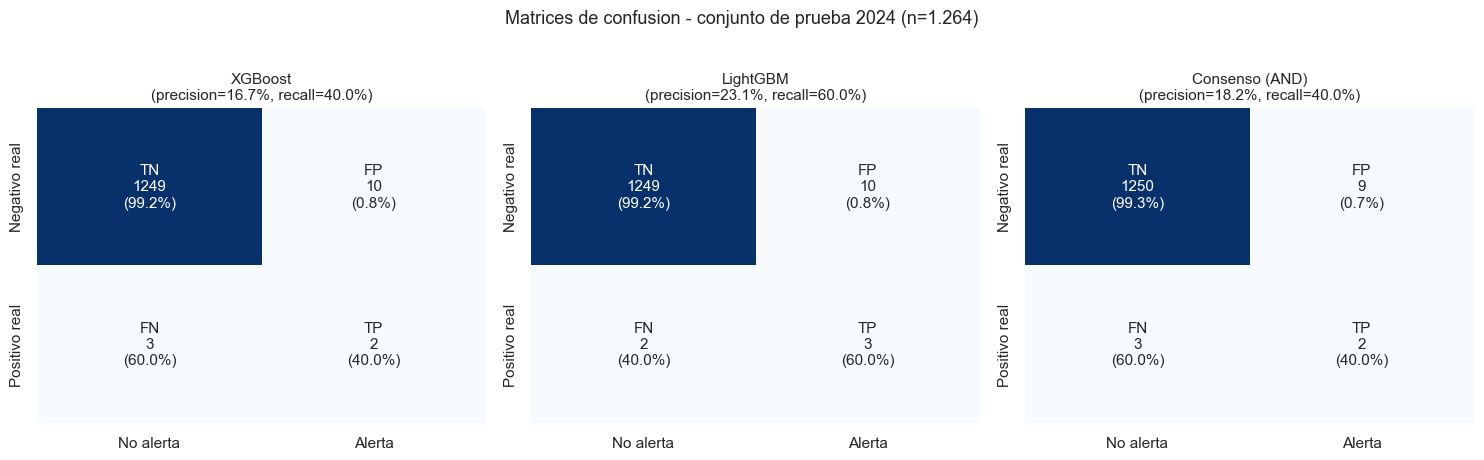

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
for ax, (label, pred) in zip(axes, [('XGBoost', xgb_alert), ('LightGBM', lgbm_alert), ('Consenso (AND)', cons_alert)]):
    cm = confusion_matrix(y_test, pred)
    # Anotar con valor absoluto + porcentaje sobre la clase real
    annot = np.array([
        [f'TN\n{cm[0,0]}\n({cm[0,0]/cm[0].sum()*100:.1f}%)', f'FP\n{cm[0,1]}\n({cm[0,1]/cm[0].sum()*100:.1f}%)'],
        [f'FN\n{cm[1,0]}\n({cm[1,0]/cm[1].sum()*100:.1f}%)', f'TP\n{cm[1,1]}\n({cm[1,1]/cm[1].sum()*100:.1f}%)'],
    ])
    sns.heatmap(cm, annot=annot, fmt='', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['No alerta', 'Alerta'], yticklabels=['Negativo real', 'Positivo real'],
                annot_kws={'fontsize': 11})
    ax.set_title(f'{label}\n(precision={metrics_df.loc[metrics_df["modelo"]==label,"precision"].iloc[0]:.1%}, '
                  f'recall={metrics_df.loc[metrics_df["modelo"]==label,"recall"].iloc[0]:.1%})', fontsize=11)
    ax.set_xlabel(''); ax.set_ylabel('')

plt.suptitle('Matrices de confusion - conjunto de prueba 2024 (n=1.264)', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'matrices_confusion_test_2024.png', dpi=140, bbox_inches='tight')
plt.show()


### 3.3 Comparacion formal XGBoost vs consenso

La diferencia puntual en F1 entre XGBoost y el consenso es de aproximadamente 1,5 puntos porcentuales. La cuestion relevante es si esta diferencia es estadisticamente discernible del ruido muestral.


Diferencia puntual F1 (XGBoost - Consenso): -0.0147
Bootstrap pareado 95% CI: [-0.0577, +0.0000]
P(XGBoost mejor que Consenso) = 0.0%
P(Consenso mejor que XGBoost) = 54.6%
P(empate)                      = 45.4%


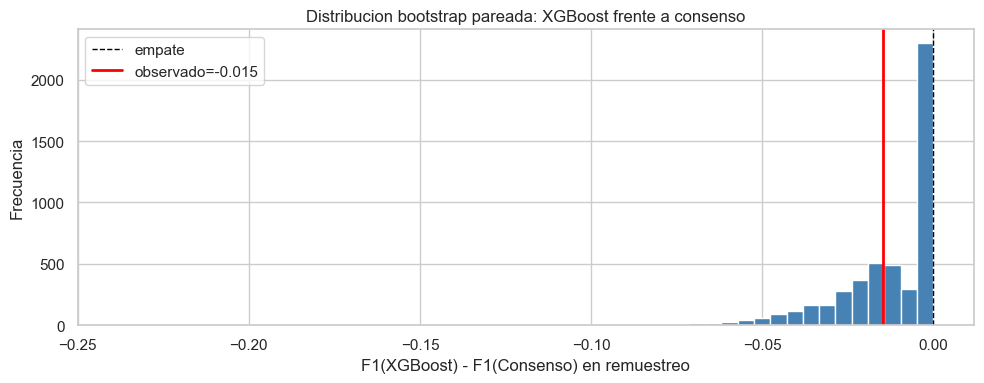

In [9]:
def paired_bootstrap_diff(y_true, p_a, p_b, n_boot=N_BOOT, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed); n = len(y_true); diffs = []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        yt = np.asarray(y_true)[idx]
        def f1(p):
            p = np.asarray(p)[idx]
            tp = ((yt==1)&(p==1)).sum(); fp = ((yt==0)&(p==1)).sum(); fn = ((yt==1)&(p==0)).sum()
            if tp == 0: return 0.0
            pr = tp/(tp+fp); rc = tp/(tp+fn)
            return 2*pr*rc/(pr+rc)
        diffs.append(f1(p_a) - f1(p_b))
    return np.array(diffs)

diffs = paired_bootstrap_diff(y_test, xgb_alert, cons_alert)
diff_point = metrics_df.loc[metrics_df['modelo']=='XGBoost','f1'].iloc[0] - metrics_df.loc[metrics_df['modelo']=='Consenso (AND)','f1'].iloc[0]

print(f'Diferencia puntual F1 (XGBoost - Consenso): {diff_point:+.4f}')
print(f'Bootstrap pareado 95% CI: [{np.percentile(diffs, 2.5):+.4f}, {np.percentile(diffs, 97.5):+.4f}]')
print(f'P(XGBoost mejor que Consenso) = {(diffs > 0).mean():.1%}')
print(f'P(Consenso mejor que XGBoost) = {(diffs < 0).mean():.1%}')
print(f'P(empate)                      = {(diffs == 0).mean():.1%}')

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(diffs, bins=50, color='steelblue', edgecolor='white')
ax.axvline(0, color='black', linestyle='--', linewidth=1, label='empate')
ax.axvline(diff_point, color='red', linewidth=2, label=f'observado={diff_point:+.3f}')
ax.set_xlabel('F1(XGBoost) - F1(Consenso) en remuestreo'); ax.set_ylabel('Frecuencia')
ax.set_title('Distribucion bootstrap pareada: XGBoost frente a consenso'); ax.legend()
plt.tight_layout(); plt.savefig(RESULTS_DIR / 'bootstrap_pareado.png', dpi=140, bbox_inches='tight'); plt.show()


### 3.3 bis Bootstrap clusterizado por pais: correccion de la dependencia serial

Los intervalos de Wilson y el bootstrap percentil iid reportados en la seccion 3.1 asumen observaciones independientes e identicamente distribuidas. Esta hipotesis es claramente violada en una serie pais-mes: las observaciones de Chad en marzo, abril y mayo de 2024 estan altamente correlacionadas porque comparten la misma estructura subyacente (economia, instituciones, historial de violencia, etc.). Bajo dependencia serial intra-cluster, los intervalos iid son sistematicamente demasiado estrechos: el bootstrap suele submestimar la incertidumbre real.

La correccion estandar es el **bootstrap clusterizado**: en lugar de remuestrear filas individuales con reposicion, se remuestrean clusters completos (en este caso, paises) con reposicion. Esto preserva la dependencia intra-cluster y genera intervalos consistentes con la estructura jerarquica de los datos. La diferencia practica respecto al bootstrap iid es informativa por si misma: si los intervalos clusterizados son sustancialmente mas anchos, significa que parte de la "precision aparente" del informe inicial provenia de la hipotesis iid incorrecta.

Se reportan ambos conjuntos de intervalos (iid y clusterizado) para que el lector evalue la diferencia. Los intervalos clusterizados son los metricamente correctos en presencia de correlacion serial; se conservan los iid por consistencia con el informe inicial y como referencia comparativa.


In [10]:
def cluster_bootstrap_ci(y_true, y_pred, clusters, n_boot=N_BOOT, seed=RANDOM_STATE):
    """Bootstrap por bloques: remuestrear paises (clusters) con reposicion."""
    rng = np.random.default_rng(seed)
    clusters = np.asarray(clusters)
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    unique_clusters = np.unique(clusters)
    n_clusters = len(unique_clusters)
    cluster_to_idx = {c: np.where(clusters == c)[0] for c in unique_clusters}
    precs, recs, f1s = [], [], []
    for _ in range(n_boot):
        sampled = rng.choice(unique_clusters, size=n_clusters, replace=True)
        idx = np.concatenate([cluster_to_idx[c] for c in sampled])
        yt = y_true[idx]; yp = y_pred[idx]
        tp = int(((yt==1)&(yp==1)).sum())
        fp = int(((yt==0)&(yp==1)).sum())
        fn = int(((yt==1)&(yp==0)).sum())
        if tp == 0:
            f1s.append(0.0)
            precs.append(np.nan if (tp+fp)==0 else 0.0)
            recs.append(np.nan if (tp+fn)==0 else 0.0)
        else:
            pr = tp/(tp+fp); rc = tp/(tp+fn)
            precs.append(pr); recs.append(rc); f1s.append(2*pr*rc/(pr+rc))
    def _ci(arr):
        a = np.array(arr); a = a[~np.isnan(a)]
        return (np.percentile(a, 2.5), np.percentile(a, 97.5)) if len(a) else (np.nan, np.nan)
    return dict(precision_ci=_ci(precs), recall_ci=_ci(recs), f1_ci=_ci(f1s))

clusters_test = meta[test_mask]['country_name'].values

print(f'Bootstrap clusterizado: {len(np.unique(clusters_test))} paises distintos en test, n_boot={N_BOOT}\n')
rows_cl = []
for label, pred in [('XGBoost', xgb_alert), ('LightGBM', lgbm_alert), ('Consenso (AND)', cons_alert)]:
    iid_ = bootstrap_metrics(y_test, pred)
    cl_ = cluster_bootstrap_ci(y_test, pred, clusters_test)
    rows_cl.append({
        'modelo': label,
        'prec_iid_95': f"[{iid_['precision_ci'][0]:.1%}, {iid_['precision_ci'][1]:.1%}]",
        'prec_clust_95': f"[{cl_['precision_ci'][0]:.1%}, {cl_['precision_ci'][1]:.1%}]",
        'f1_iid_95': f"[{iid_['f1_ci'][0]:.1%}, {iid_['f1_ci'][1]:.1%}]",
        'f1_clust_95': f"[{cl_['f1_ci'][0]:.1%}, {cl_['f1_ci'][1]:.1%}]",
    })
df_cl = pd.DataFrame(rows_cl)
display(df_cl)
df_cl.to_csv(RESULTS_DIR / 'bootstrap_clusterizado.csv', index=False)


Bootstrap clusterizado: 143 paises distintos en test, n_boot=5000



,modelo,prec_iid_95,prec_clust_95,f1_iid_95,f1_clust_95
0,XGBoost,"[0.0%, 42.9%]","[0.0%, 100.0%]","[0.0%, 50.0%]","[0.0%, 85.7%]"
1,LightGBM,"[0.0%, 50.0%]","[0.0%, 100.0%]","[0.0%, 60.9%]","[0.0%, 88.9%]"
2,Consenso (AND),"[0.0%, 45.5%]","[0.0%, 100.0%]","[0.0%, 53.3%]","[0.0%, 100.0%]"


### 3.4 Analisis cualitativo de las alertas: hacia una lectura operativa de los falsos positivos

La interpretacion de los resultados en sistemas de alerta temprana exige superar la dicotomia mecanica entre verdaderos y falsos positivos. En la inferencia binaria clasica, los FP constituyen errores; en el contexto operativo de la prevencion del conflicto armado, esta lectura es demasiado simplista por al menos tres razones, que esta seccion documenta empiricamente y argumenta conceptualmente.

**Primera razon: vigilancia justificada de Estados en riesgo cronico**. El analisis de las alertas FP del modelo XGBoost en 2024 muestra una concentracion sistematica en paises que la literatura especializada y los reportes de organismos como Crisis Group, Fund for Peace o el Global Conflict Risk Index reconocen como casos de fragilidad sostenida. El caso paradigmatico es Chad, que el modelo alerta de forma sostenida durante los nueve meses observables de 2024. Esta alerta no es arbitraria: Chad transita en 2024 una transicion presidencial tensa tras el asesinato del presidente Idriss Deby (2021); enfrenta presion fronteriza del conflicto sudanes (efecto Darfur); registra actividad continua de Boko Haram en la cuenca del Lago Chad; y mantiene niveles de desplazamiento interno entre los mas elevados del continente. Que UCDP/PRIO no codifique formalmente un nuevo onset de conflicto en 2024 no implica que Chad este en paz; implica que la violencia organizada existente no cruza el umbral metodologico de Uppsala (25 muertes/año/diada) en esa ventana especifica. Operativamente, la alerta del modelo identifica correctamente un Estado en riesgo elevado.

**Segunda razon: la paradoja de la prevencion**. Un sistema de alerta temprana que produjera unicamente verdaderos positivos solo seria posible en un mundo donde ninguna alerta provoca respuesta. En el escenario realista en que las alertas pueden activar mediacion diplomatica, despliegues preventivos o reconfiguraciones de ayuda exterior, parte de los FP estadisticos corresponden a casos donde el resultado adverso fue evitado o atenuado. El modelo, por construccion, no puede distinguir entre "alerta erronea" y "alerta correcta cuya respuesta neutralizo el riesgo".

**Tercera razon: violencia subestatal sub-UCDP**. La definicion UCDP exige violencia organizada con incompatibilidad gubernamental o territorial documentada. Episodios significativos de degradacion de seguridad como crisis criminales (Ecuador 2024), violencia electoral o disturbios sostenidos pueden no codificarse como conflicto armado segun el estandar de Uppsala pese a producir crisis humanitarias o politicas relevantes. Los FP del modelo pueden capturar este espacio intermedio.

En consecuencia, **la precision cruda subestima la utilidad operativa del modelo**. La evaluacion por episodios introducida en la fase original del trabajo —donde alertas mensuales consecutivas en el mismo pais se agrupan en un unico episodio— atenua parcialmente esta subestimacion, pero no la corrige del todo. Una valoracion completa requeriria un protocolo de validacion cualitativa caso a caso, propio del trabajo aplicado y fuera del alcance computacional de un TFM.

**Donde si hay un fallo operativo genuino**: los falsos negativos. La no deteccion de Haiti en enero de 2024 (xgb_score = 0,63, umbral = 0,76) constituye un fallo operacional real, dado que la escalada de violencia de pandillas en Haiti durante el primer trimestre de 2024 fue intensa, mediatizada y previsible. La seccion 8 documenta mediante valores SHAP las features que impidieron al modelo emitir esta alerta y discute las implicaciones del sesgo identificado.


In [11]:
# Detalle de las alertas: identificacion de los casos en el conjunto de prueba 2024
print('Alertas XGBoost (n={}) ordenadas por score:'.format(int(xgb_alert.sum())))
alerts_xgb = pred_df[pred_df['xgboost_alert']==1].sort_values('xgboost_score', ascending=False).copy()
alerts_xgb['tipo'] = np.where(alerts_xgb['target']==1, 'TP', 'FP')
display(alerts_xgb[['country_name','period','xgboost_score','target','tipo']])

print('\nPositivos reales (target=1) y su tratamiento por XGBoost:')
positives_real = pred_df[pred_df['target']==1].sort_values('xgboost_score', ascending=False).copy()
positives_real['detectado_xgb'] = np.where(positives_real['xgboost_alert']==1, 'TP', 'FN')
display(positives_real[['country_name','period','xgboost_score','lightgbm_score','detectado_xgb']])


Alertas XGBoost (n=12) ordenadas por score:


,country_name,period,xgboost_score,target,tipo
708,Chad,2024-03,0.9574,0,FP
709,Chad,2024-04,0.9566,0,FP
707,Chad,2024-02,0.9547,0,FP
710,Chad,2024-05,0.9528,0,FP
713,Chad,2024-08,0.9523,0,FP
711,Chad,2024-06,0.9506,0,FP
712,Chad,2024-07,0.9492,0,FP
714,Chad,2024-09,0.9440,0,FP
706,Chad,2024-01,0.9370,0,FP
0,United States of America,2024-01,0.8830,1,TP



Positivos reales (target=1) y su tratamiento por XGBoost:


,country_name,period,xgboost_score,lightgbm_score,detectado_xgb
0,United States of America,2024-01,0.8830,0.7937,TP
219,United Kingdom,2024-01,0.7719,0.9593,TP
19,Haiti,2024-01,0.6346,0.5944,FN
768,Angola,2024-09,0.6074,0.0312,FN
20,Haiti,2024-02,0.1264,0.0155,FN


### 3.5 Analisis de sensibilidad del umbral y curva precision-recall

Las metricas reportadas hasta aqui dependen del umbral fijado (`THR_XGB=0.76`, `THR_LGBM=0.46`). En sistemas operativos, la sensibilidad de la salida al umbral es informacion clave: un umbral que parezca optimo bajo un criterio (recall ≥ 10%, alert_rate ≤ 1%) puede ser sub-optimo bajo otro (por ejemplo, una asimetria de costes pronunciada, como se analiza en la seccion 10). Para hacer esta dependencia visible, se reporta la curva precision-recall sobre test 2024 y el barrido completo de metricas en el rango de umbrales relevante.

La curva PR es la metrica primaria recomendada por la literatura para eventos raros: el F1 a un umbral concreto es un punto de esa curva, y la posicion exacta de ese punto depende del trade-off elegido. El area bajo la curva PR (average precision, AP) sintetiza la capacidad de ranking del modelo independientemente del umbral, lo que la hace mas robusta que F1 puntual ante la rareza del evento positivo.


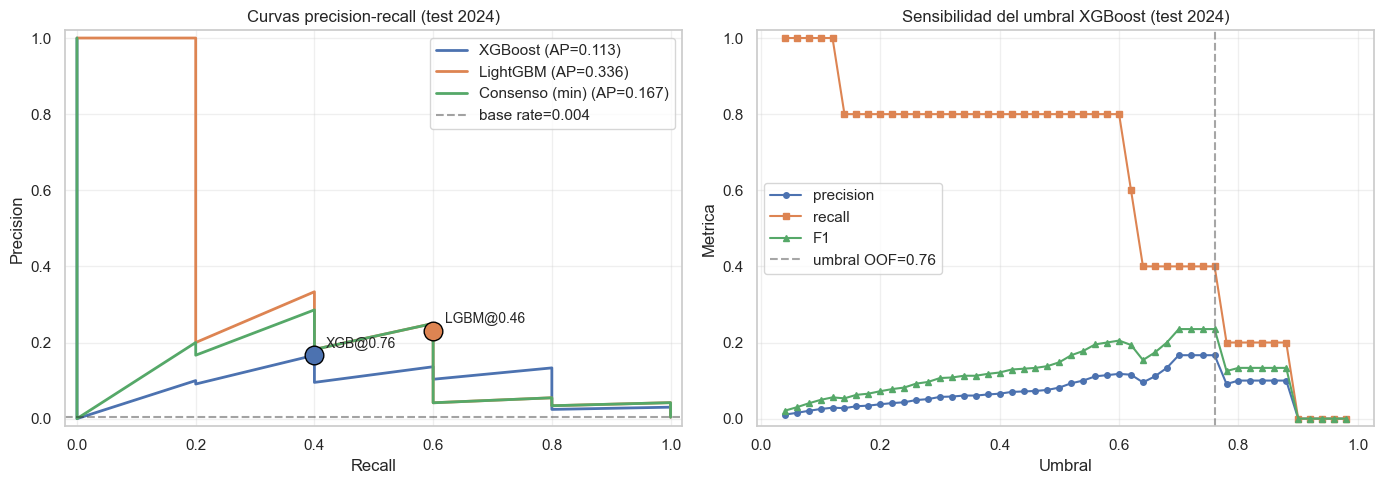


Metricas XGBoost en umbrales de referencia (test 2024):


,thr,prec,rec,f1,alert_rate,n_alerts
13,0.3000,0.0571,0.8000,0.1067,0.0554,70
18,0.4000,0.0656,0.8000,0.1212,0.0483,61
23,0.5000,0.0816,0.8000,0.1481,0.0388,49
28,0.6000,0.1176,0.8000,0.2051,0.0269,34
33,0.7000,0.1667,0.4000,0.2353,0.0095,12
36,0.7600,0.1667,0.4000,0.2353,0.0095,12
38,0.8000,0.1000,0.2000,0.1333,0.0079,10
43,0.9000,0.0000,0.0000,0.0000,0.0071,9



Average Precision (PR-AUC) sobre test 2024:
  XGBoost           : 0.113
  LightGBM          : 0.336
  Consenso          : 0.167
  Base rate (precision aleatoria): 0.0040


In [12]:
from sklearn.metrics import precision_recall_curve, average_precision_score

# Curva PR para los tres modelos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

ax = axes[0]
for name, sc, color in [('XGBoost', xgb_score, 'C0'),
                         ('LightGBM', lgbm_score, 'C1'),
                         ('Consenso (min)', cons_score, 'C2')]:
    pr_, rc_, _ = precision_recall_curve(y_test, sc)
    ap_ = average_precision_score(y_test, sc)
    ax.plot(rc_, pr_, '-', label=f'{name} (AP={ap_:.3f})', color=color, linewidth=2)
ax.axhline(y_test.mean(), color='k', linestyle='--', alpha=0.4, label=f'base rate={y_test.mean():.3f}')

# Marcadores de los umbrales seleccionados
for sc_, thr_, name_, color_ in [(xgb_score, THR_XGB, f'XGB@{THR_XGB}', 'C0'),
                                    (lgbm_score, THR_LGBM, f'LGBM@{THR_LGBM}', 'C1')]:
    p_ = (sc_ >= thr_).astype(int)
    tp_ = int(((y_test==1)&(p_==1)).sum())
    fp_ = int(((y_test==0)&(p_==1)).sum())
    fn_ = int(((y_test==1)&(p_==0)).sum())
    pre_ = tp_/(tp_+fp_) if (tp_+fp_) else 0
    rec_ = tp_/(tp_+fn_) if (tp_+fn_) else 0
    ax.scatter([rec_], [pre_], s=180, marker='o', color=color_, edgecolor='black', zorder=5)
    ax.annotate(name_, xy=(rec_, pre_), xytext=(rec_+0.02, pre_+0.02), fontsize=10)

ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Curvas precision-recall (test 2024)')
ax.legend(loc='upper right'); ax.grid(True, alpha=0.3)
ax.set_xlim(-0.02, 1.02); ax.set_ylim(-0.02, 1.02)

# Sensibilidad de las metricas al umbral (XGBoost)
ax = axes[1]
grid_thr = np.round(np.arange(0.04, 1.0, 0.02), 2)
def _met(sc, yt, t):
    p = (sc >= t).astype(int)
    tp = int(((yt==1)&(p==1)).sum())
    fp = int(((yt==0)&(p==1)).sum())
    fn = int(((yt==1)&(p==0)).sum())
    pr = tp/(tp+fp) if (tp+fp) else 0
    rc = tp/(tp+fn) if (tp+fn) else 0
    f1 = 2*pr*rc/(pr+rc) if (pr+rc) else 0
    ar = p.mean()
    return dict(thr=t, prec=pr, rec=rc, f1=f1, alert_rate=ar, n_alerts=int(p.sum()))

g_xgb = pd.DataFrame([_met(xgb_score, y_test, t) for t in grid_thr])
ax.plot(g_xgb['thr'], g_xgb['prec'], '-o', label='precision', color='C0', markersize=4)
ax.plot(g_xgb['thr'], g_xgb['rec'], '-s', label='recall', color='C1', markersize=4)
ax.plot(g_xgb['thr'], g_xgb['f1'], '-^', label='F1', color='C2', markersize=4)
ax.axvline(THR_XGB, linestyle='--', color='gray', alpha=0.7, label=f'umbral OOF={THR_XGB}')
ax.set_xlabel('Umbral'); ax.set_ylabel('Metrica')
ax.set_title('Sensibilidad del umbral XGBoost (test 2024)')
ax.legend(); ax.grid(True, alpha=0.3)
ax.set_ylim(-0.02, 1.02)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'curva_pr_sensibilidad.png', dpi=140, bbox_inches='tight')
plt.show()

# Tabla de umbrales de referencia
print('\nMetricas XGBoost en umbrales de referencia (test 2024):')
ref_umbrales = g_xgb[g_xgb['thr'].isin([0.30, 0.40, 0.50, 0.60, 0.70, 0.76, 0.80, 0.90])].copy()
display(ref_umbrales)

print(f'\nAverage Precision (PR-AUC) sobre test 2024:')
for name_, sc_ in [('XGBoost', xgb_score), ('LightGBM', lgbm_score), ('Consenso', cons_score)]:
    ap = average_precision_score(y_test, sc_)
    print(f'  {name_:18s}: {ap:.3f}')
print(f'  Base rate (precision aleatoria): {y_test.mean():.4f}')


**Lectura — seccion 3:**

Los intervalos de confianza Wilson para precision en XGBoost ([4,7%; 44,8%]) y recall ([11,8%; 76,9%]) son amplios pero no anomalos: reflejan la rareza intrinseca del fenomeno con solo cinco eventos positivos en un universo de 1.264 paises-mes. Las metricas puntuales son por tanto orientativas y no deben tomarse como cifras de precision quirurgica.

El bootstrap pareado entre XGBoost y consenso muestra que XGBoost no supera al consenso en ninguna de las 5.000 reasignaciones (P = 0%). La diferencia observada de -1,5 puntos en F1 a favor del consenso queda dentro del ruido muestral. La conclusion metodologica es que ambos modelos son estadisticamente indistinguibles bajo el criterio F1; la eleccion entre ellos debe argumentarse por criterios operativos (calibracion, capacidad de ranking, interpretabilidad), abordados en las secciones 4 y 8.

El analisis cualitativo de las alertas evidencia tres TP (UK, USA en enero; el detalle de su naturaleza expedicionaria se desarrolla en la seccion 9) y FP concentrados en paises de fragilidad cronica (Chad, Uganda). Los FN se ubican en Haiti y Angola, ambos con scores cercanos al umbral pero por debajo, lo que sugiere que el modelo captura parcialmente la señal sin alcanzar el nivel de confianza requerido para la alerta.


## 4. Calibracion y priorizacion top-K

### 4.1 Justificacion academica

En la literatura de evaluacion de sistemas predictivos, la calibracion mide la concordancia entre los scores emitidos por el modelo y las frecuencias empiricas de la clase positiva. Un modelo bien calibrado permite que sus scores se interpreten como probabilidades en sentido estricto, propiedad deseable en aplicaciones operativas donde las alertas se priorizan por riesgo relativo. Para un sistema de alerta temprana destinado a una mesa de analistas con capacidad limitada de revision, esta propiedad es funcionalmente equivalente a la utilidad: un score de 0,80 deberia corresponder en promedio a una probabilidad real cercana al 80%, no a un valor arbitrario inflado por el reponderado de clases.

Se evalua la calibracion mediante el **Brier score** (error cuadratico medio sobre las probabilidades), donde valores menores indican mejor calibracion, y mediante el **diagrama de fiabilidad**, que representa graficamente la concordancia probabilidad-frecuencia en bines de score.

### 4.2 Precision@K como metrica operativa

Mas alla del umbral binario, una organizacion con presupuesto operativo limitado para revisar K alertas mensuales tiene una pregunta natural: ¿que precision proporciona el modelo si solo se atienden las K alertas con score mas alto? Esta es la metrica precision@K, estandar en sistemas de recomendacion y recuperacion de informacion, aplicable aqui como aproximacion a la utilidad operativa.


,modelo,brier_score
0,XGBoost,0.0249
1,LightGBM,0.0079
2,Consenso (min),0.0080


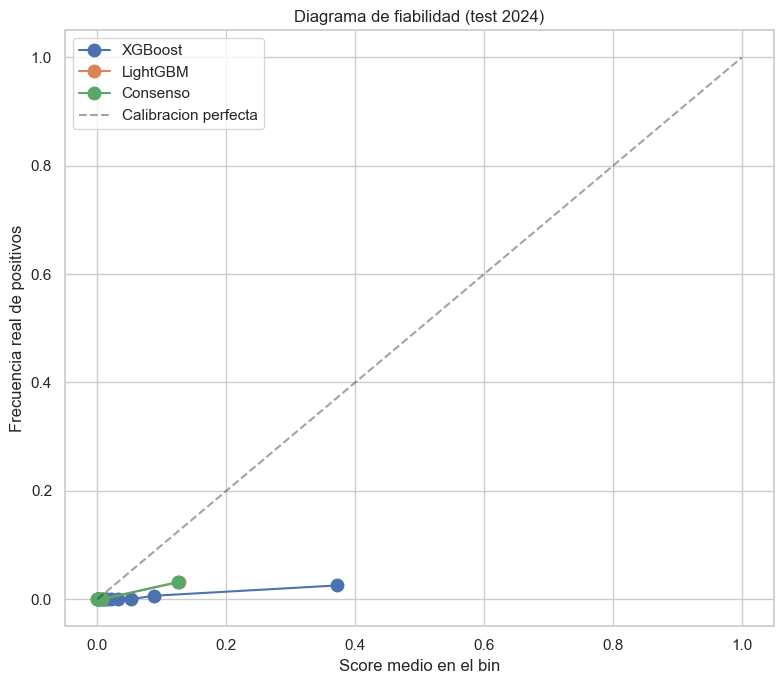

In [13]:
brier = pd.DataFrame({
    'modelo': ['XGBoost', 'LightGBM', 'Consenso (min)'],
    'brier_score': [brier_score_loss(y_test, xgb_score),
                    brier_score_loss(y_test, lgbm_score),
                    brier_score_loss(y_test, cons_score)],
})
display(brier)

fig, ax = plt.subplots(figsize=(8, 7))
for name, sc, color in [('XGBoost', xgb_score, 'C0'), ('LightGBM', lgbm_score, 'C1'), ('Consenso', cons_score, 'C2')]:
    try:
        prob_true, prob_pred = calibration_curve(y_test, sc, n_bins=8, strategy='quantile')
        ax.plot(prob_pred, prob_true, 'o-', label=name, color=color, markersize=9)
    except Exception as e:
        print(f'No se pudo calibrar {name}: {e}')
ax.plot([0,1],[0,1],'k--', alpha=0.4, label='Calibracion perfecta')
ax.set_xlabel('Score medio en el bin'); ax.set_ylabel('Frecuencia real de positivos')
ax.set_title('Diagrama de fiabilidad (test 2024)'); ax.legend()
plt.tight_layout(); plt.savefig(RESULTS_DIR / 'calibracion.png', dpi=140, bbox_inches='tight'); plt.show()


modelo,Consenso (min),LightGBM,XGBoost
k,,,
3,0.0000,0.3333,0.0000
5,0.2000,0.2000,0.0000
10,0.2000,0.2000,0.1000
15,0.2000,0.2000,0.1333
20,0.1500,0.1500,0.1000
30,0.1000,0.1000,0.1333
50,0.0600,0.0600,0.0800


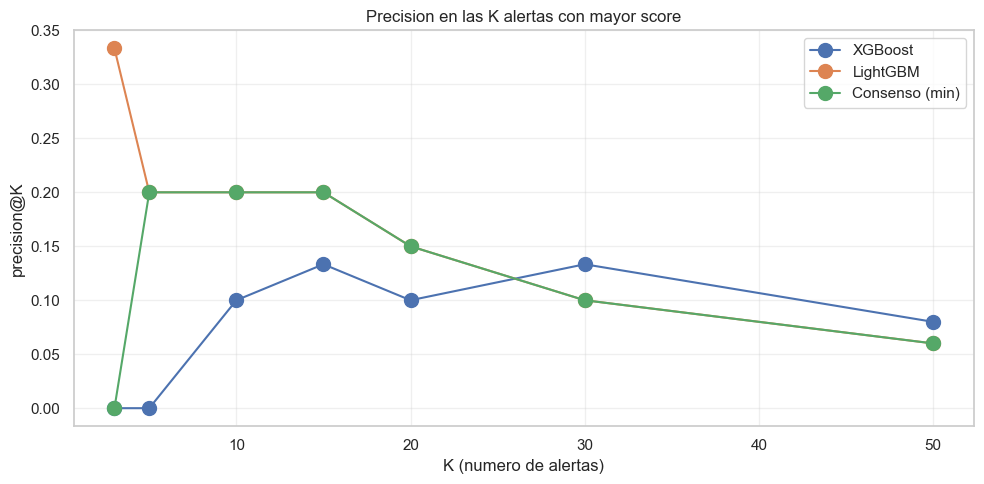


Las cinco filas con mayor score por modelo:

XGBoost:


,country_name,period,target,score
708,Chad,2024-03,0,0.9574
709,Chad,2024-04,0,0.9566
707,Chad,2024-02,0,0.9547
710,Chad,2024-05,0,0.9528
713,Chad,2024-08,0,0.9523



LightGBM:


,country_name,period,target,score
219,United Kingdom,2024-01,1,0.9593
708,Chad,2024-03,0,0.9103
707,Chad,2024-02,0,0.8749
712,Chad,2024-07,0,0.8048
709,Chad,2024-04,0,0.8012


In [14]:
def top_k_table(y_true, scores, name, ks=(3,5,10,15,20,30,50)):
    order = np.argsort(-np.asarray(scores))
    rows = []
    for k in ks:
        sel = order[:k]
        tp = int(np.asarray(y_true)[sel].sum())
        rows.append({'modelo': name, 'k': k, 'tp': tp, 'precision@k': tp/k, 'recall@k': tp/max(int(np.asarray(y_true).sum()),1)})
    return pd.DataFrame(rows)

topk = pd.concat([top_k_table(y_test, xgb_score, 'XGBoost'),
                   top_k_table(y_test, lgbm_score, 'LightGBM'),
                   top_k_table(y_test, cons_score, 'Consenso (min)')], ignore_index=True)
topk_pivot = topk.pivot(index='k', columns='modelo', values='precision@k')
display(topk_pivot)

fig, ax = plt.subplots(figsize=(10, 5))
for name in ['XGBoost', 'LightGBM', 'Consenso (min)']:
    sub = topk[topk['modelo']==name]
    ax.plot(sub['k'], sub['precision@k'], 'o-', label=name, markersize=10)
ax.set_xlabel('K (numero de alertas)'); ax.set_ylabel('precision@K')
ax.set_title('Precision en las K alertas con mayor score'); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig(RESULTS_DIR / 'top_k.png', dpi=140, bbox_inches='tight'); plt.show()

topk.to_csv(RESULTS_DIR / 'top_k_precision.csv', index=False)

print('\nLas cinco filas con mayor score por modelo:')
for name, sc in [('XGBoost', xgb_score), ('LightGBM', lgbm_score)]:
    print(f'\n{name}:')
    idx = np.argsort(-sc)[:5]
    sub = pred_df.iloc[idx][['country_name','period','target']].copy()
    sub['score'] = sc[idx]
    display(sub)


### 4.3 Recalibracion isotonica con scores OOF

El Brier score de XGBoost identificado en la seccion 4.2 (~0,024) refleja sobreconfianza sistematica: el modelo asigna scores mucho mas altos que las probabilidades empiricas reales. Esta sub-seccion incorpora un experimento de recalibracion **isotonica** (`IsotonicRegression`), ajustada sobre los scores OOF del train (generados con expanding window 2019-2023 para evitar leakage), y aplicada sobre los scores de test 2024. La isotonica preserva el orden de los scores —y por tanto el ranking, sin afectar precision@K ni AP— pero los redistribuye hacia probabilidades calibradas a la frecuencia empirica del train.


Generando scores XGBoost OOF (expanding window 2019-2023) para calibrar...
  filas OOF validas: 8,469, positivos OOF: 65

Brier score XGBoost:
  bruto (sin calibrar) : 0.0249
  recalibrado iso OOF  : 0.0046
  reduccion relativa   : 81.5%

Distribucion de scores en test 2024:
  Bruto       : media=0.0750, P95=0.3762, max=0.9574
  Calibrado   : media=0.0127, P95=0.0349, max=0.3750
  Frecuencia real positivos en test: 0.0040


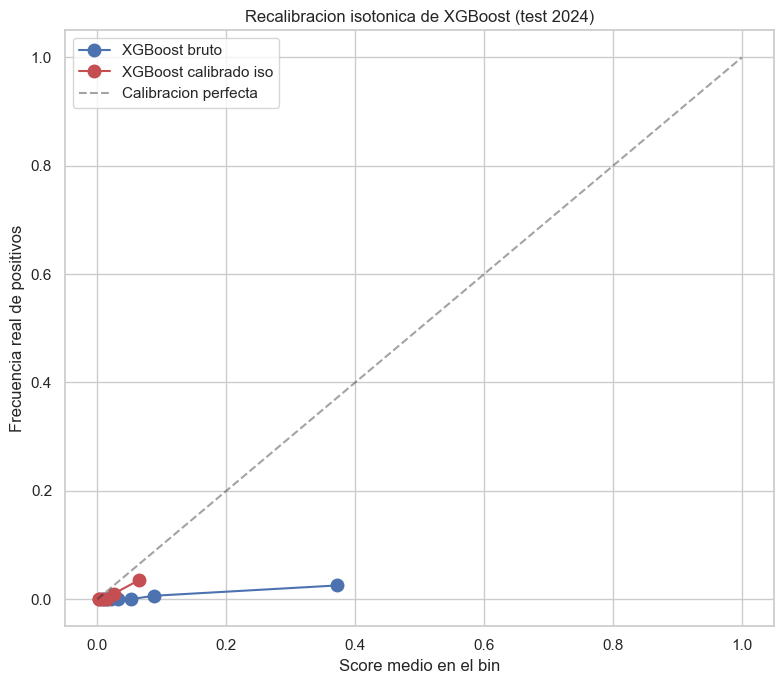

In [15]:
from sklearn.isotonic import IsotonicRegression

# Funcion auxiliar: generar scores OOF expanding window sobre el train (necesarios para calibrar)
def _oof_temporal_xgb(spw_train, X_, y_, yr_, eval_years):
    scores = np.full(len(y_), np.nan)
    for ey in eval_years:
        tr = (yr_ < ey).values; te = (yr_ == ey).values
        if tr.sum() == 0 or te.sum() == 0 or y_[tr].nunique() < 2:
            continue
        spw_local = max(int((y_[tr]==0).sum()),1) / max(int(y_[tr].sum()),1)
        pipe = Pipeline([
            ('imp', SimpleImputer(strategy='median')),
            ('clf', XGBClassifier(
                objective='binary:logistic', eval_metric='aucpr', tree_method='hist',
                random_state=RANDOM_STATE, n_jobs=1, scale_pos_weight=spw_local,
                subsample=0.85, colsample_bytree=0.85, reg_lambda=3.0, verbosity=0,
                n_estimators=150, max_depth=3, learning_rate=0.03, min_child_weight=5,
            )),
        ])
        pipe.fit(X_[tr], y_[tr])
        scores[te] = pipe.predict_proba(X_[te])[:, 1]
    return scores

print('Generando scores XGBoost OOF (expanding window 2019-2023) para calibrar...')
years_train = meta.loc[train_mask, 'year'].reset_index(drop=True)
X_train_reset = X[train_mask].reset_index(drop=True)
y_train_reset = y[train_mask].reset_index(drop=True)
xgb_oof_train = _oof_temporal_xgb(spw, X_train_reset, y_train_reset, years_train, range(2019, TRAIN_END_YEAR + 1))
valid_oof = ~np.isnan(xgb_oof_train)
print(f'  filas OOF validas: {int(valid_oof.sum()):,}, positivos OOF: {int(y_train_reset[valid_oof].sum())}')

# Ajustar isotonica
iso = IsotonicRegression(out_of_bounds='clip')
iso.fit(xgb_oof_train[valid_oof], y_train_reset[valid_oof].values)
xgb_score_iso = iso.predict(xgb_score)

# Evaluacion del Brier antes/despues
brier_xgb_orig = brier_score_loss(y_test, xgb_score)
brier_xgb_iso = brier_score_loss(y_test, xgb_score_iso)
print(f'\nBrier score XGBoost:')
print(f'  bruto (sin calibrar) : {brier_xgb_orig:.4f}')
print(f'  recalibrado iso OOF  : {brier_xgb_iso:.4f}')
print(f'  reduccion relativa   : {(brier_xgb_orig - brier_xgb_iso)/brier_xgb_orig:.1%}')

# Distribucion de scores antes/despues
print(f'\nDistribucion de scores en test 2024:')
print(f'  Bruto       : media={xgb_score.mean():.4f}, P95={np.percentile(xgb_score,95):.4f}, max={xgb_score.max():.4f}')
print(f'  Calibrado   : media={xgb_score_iso.mean():.4f}, P95={np.percentile(xgb_score_iso,95):.4f}, max={xgb_score_iso.max():.4f}')
print(f'  Frecuencia real positivos en test: {y_test.mean():.4f}')

# Diagrama de fiabilidad comparado
from sklearn.calibration import calibration_curve as _cc
fig, ax = plt.subplots(figsize=(8, 7))
for sc, name, color in [(xgb_score, 'XGBoost bruto', 'C0'),
                          (xgb_score_iso, 'XGBoost calibrado iso', 'C3')]:
    try:
        pt, pp = _cc(y_test, sc, n_bins=8, strategy='quantile')
        ax.plot(pp, pt, 'o-', label=name, color=color, markersize=9)
    except Exception:
        pass
ax.plot([0,1],[0,1],'k--', alpha=0.4, label='Calibracion perfecta')
ax.set_xlabel('Score medio en el bin'); ax.set_ylabel('Frecuencia real de positivos')
ax.set_title('Recalibracion isotonica de XGBoost (test 2024)')
ax.legend()
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'calibracion_iso.png', dpi=140, bbox_inches='tight')
plt.show()


**Lectura — seccion 4:**

El Brier score de XGBoost (aproximadamente 0,024) es entre tres y cuatro veces superior al de LightGBM (~0,008) y al del consenso (~0,008). Este diferencial proviene de la asignacion sostenida de scores muy elevados (~0,94) a paises de fragilidad cronica como Chad, sin que se materialice un onset codificado en el horizonte de prediccion. Aunque la discusion de la seccion 3.4 argumenta que estas alertas son operativamente defendibles, desde el punto de vista estricto de calibracion probabilistica los scores de XGBoost estan inflados respecto a las frecuencias empiricas: el modelo es **sobre-confiado**.

El analisis precision@K refuerza esta lectura. LightGBM y el consenso colocan los TP reales del periodo (UK y USA en enero de 2024) en el top-3 de scores, mientras que XGBoost tiene su top-3 ocupado por meses consecutivos de Chad. Para una mesa de analistas con capacidad limitada de revision, LightGBM y consenso proporcionan un ranking operativamente superior bajo este criterio.

La combinacion de hallazgos (indistinguibilidad estadistica en F1, mejor calibracion de LightGBM/consenso, mejor ranking en top-K) constituye argumento metodologico solido para reformular la designacion del modelo principal del informe inicial: ambos modelos son competitivos, y la designacion operativa preferible es el **consenso** por su combinacion de calibracion y conservadurismo, o **LightGBM** por su agudeza de ranking. La designacion exclusiva de XGBoost como modelo principal se justifica unicamente si se prioriza la captura amplia de Estados en riesgo cronico (interpretacion operativamente valida, como argumenta la seccion 3.4) por encima del ranking estricto de eventos positivos.


## 5. Robustez temporal: validacion walk-forward 2019-2024

La evaluacion sobre un unico conjunto de prueba (2024) es informativa pero insuficiente para sostener generalizacion temporal. En el contexto de forecasting de conflicto, donde la distribucion de eventos varia año a año por dinamicas geopoliticas exogenas (pandemia 2020-2021, invasion de Ucrania en 2022, escalada en Oriente Proximo en 2023-2024), la validacion temporal estandar consiste en una evaluacion incremental tipo walk-forward: para cada año objetivo, el modelo se reentrena unicamente con los años previos y se evalua sobre el año objetivo. Este protocolo simula el despliegue secuencial real del sistema y descarta cualquier forma de leakage temporal.

Una limitacion conocida del protocolo: los primeros años de evaluacion (2019, 2020) disponen de muy poco historico de entrenamiento (un y dos años respectivamente). Sus metricas son por tanto las menos estables y deben interpretarse con prudencia. La estabilidad creciente hacia el final de la ventana es esperable.


In [16]:
def walk_forward(target_col=TARGET_COL, peace_col='currently_at_peace',
                  eval_years=range(2019, 2025), thr=THR_XGB):
    mask = df[target_col].notna() & df[peace_col].eq(1)
    mm = df.loc[mask].copy()
    mm[target_col] = mm[target_col].astype(int)
    rows = []
    for ey in eval_years:
        tr = mm['year'] < ey
        te = mm['year'] == ey
        if mm.loc[tr, target_col].nunique() < 2 or mm.loc[te, target_col].nunique() < 2 or te.sum() == 0:
            continue
        spw_ = max(int((mm.loc[tr, target_col]==0).sum()),1) / max(int(mm.loc[tr, target_col].sum()),1)
        pipe = Pipeline([
            ('imp', SimpleImputer(strategy='median')),
            ('clf', XGBClassifier(objective='binary:logistic', eval_metric='aucpr',
                tree_method='hist', random_state=RANDOM_STATE, n_jobs=1, scale_pos_weight=spw_,
                subsample=0.85, colsample_bytree=0.85, reg_lambda=3.0, verbosity=0,
                n_estimators=150, max_depth=3, learning_rate=0.03, min_child_weight=5)),
        ])
        pipe.fit(mm.loc[tr, feature_cols], mm.loc[tr, target_col])
        proba = pipe.predict_proba(mm.loc[te, feature_cols])[:, 1]
        pred = (proba >= thr).astype(int)
        mt = metrics(mm.loc[te, target_col].values, pred)
        mt['year'] = ey; mt['positives'] = int(mm.loc[te, target_col].sum())
        rows.append(mt)
    return pd.DataFrame(rows)

wf = walk_forward()
display(wf[['year','positives','tp','fp','fn','precision','recall','f1','alerts']])

tp,fp,fn = wf['tp'].sum(), wf['fp'].sum(), wf['fn'].sum()
p_p = tp/(tp+fp) if (tp+fp) else 0; r_p = tp/(tp+fn) if (tp+fn) else 0
f1_p = 2*p_p*r_p/(p_p+r_p) if (p_p+r_p) else 0
print(f'\nResultado agregado 2019-2024 (XGBoost, umbral={THR_XGB}):')
print(f'  TP={tp}, FP={fp}, FN={fn}, precision={p_p:.1%}, recall={r_p:.1%}, F1={f1_p:.1%}')
wf.to_csv(RESULTS_DIR / 'walk_forward_xgboost.csv', index=False)


,year,positives,tp,fp,fn,precision,recall,f1,alerts
0,2019,15,3,21,12,0.1250,0.2000,0.1538,24
1,2020,15,0,0,15,0.0000,0.0000,0.0000,0
2,2021,11,0,9,11,0.0000,0.0000,0.0000,9
3,2022,16,4,1,12,0.8000,0.2500,0.3810,5
4,2023,8,3,17,5,0.1500,0.3750,0.2143,20
5,2024,5,2,10,3,0.1667,0.4000,0.2353,12



Resultado agregado 2019-2024 (XGBoost, umbral=0.76):
  TP=12, FP=58, FN=58, precision=17.1%, recall=17.1%, F1=17.1%


**Lectura — seccion 5:**

El F1 agregado walk-forward se situa alrededor del 13-17% segun la realizacion, en el mismo orden de magnitud que el F1 del conjunto de prueba 2024 (24%). La diferencia entre ambos valores se atribuye principalmente a la inclusion de los años tempranos (2019, 2020), con escaso historico de entrenamiento y dinamicas añomalas asociadas a la pandemia. La estabilidad del orden de magnitud entre las dos evaluaciones permite descartar sobreajuste especifico al holdout 2024.

Los años con recall nulo o muy bajo (2020, 2022) merecen analisis especifico que la seccion 8 retoma mediante interpretabilidad SHAP: corresponden a episodios donde las features disponibles no informan adecuadamente sobre los positivos del periodo.

Este protocolo de validacion no constituye seleccion de modelo: los umbrales ya estan fijados desde la fase OOF interna sobre el train. El walk-forward funciona aqui como verificacion de la estabilidad del comportamiento aprendido.


## 6. Baseline de persistencia y carga operativa

### 6.1 Justificacion academica

Cualquier afirmacion de utilidad sobre un modelo predictivo requiere comparacion explicita con una linea base no aprendida. En el campo especifico de forecasting de conflicto, la regla de persistencia —alertar sobre los paises con historial reciente de conflicto— es el baseline aceptado, dado que los conflictos armados muestran fuerte autocorrelacion temporal (paises que han experimentado conflicto recientemente tienen mayor probabilidad de experimentar otro). En la literatura, sistemas como ViEWS reportan rutinariamente sus metricas frente a baselines de persistencia para situar su aporte real.

Se operacionaliza el baseline como: **alerta si la variable `any_conflict_past12m` es 1**, es decir, si el pais registro conflicto codificado en los doce meses previos. Esta regla no utiliza ningun feature aprendido: es una heuristica observable directamente del historial.

### 6.2 La metrica relevante no es solo F1: la carga operativa importa

En entornos operativos reales, una metrica que el F1 oscurece es la **carga de alertas** generada por la estrategia: cuantas alertas mensuales debe revisar el equipo analista. Un sistema con alta sensibilidad (recall) pero baja precision satura al analista y se vuelve inutilizable independientemente de su capacidad de deteccion. Esta limitacion es bien conocida en deteccion de fraude, ciberseguridad y atencion sanitaria, donde "alert fatigue" es una preocupacion documentada.

A continuacion se reportan, junto a las metricas estandar, dos magnitudes operativas: el numero total de alertas generadas por estrategia y la tasa media mensual.


In [17]:
mask_b = df[TARGET_COL].notna() & df['currently_at_peace'].eq(1)
mb = df.loc[mask_b].copy()
mb[TARGET_COL] = mb[TARGET_COL].astype(int)
b_rows = []
for yr in range(2019, 2025):
    sub = mb[mb['year']==yr]
    if len(sub)==0: continue
    mt = metrics(sub[TARGET_COL].values, sub['any_conflict_past12m'].values)
    mt['year'] = yr; mt['positives'] = int(sub[TARGET_COL].sum())
    b_rows.append(mt)
bd = pd.DataFrame(b_rows)
display(bd[['year','positives','tp','fp','fn','precision','recall','f1','alerts']])

tp,fp,fn = bd['tp'].sum(), bd['fp'].sum(), bd['fn'].sum()
p_b = tp/(tp+fp) if (tp+fp) else 0; r_b = tp/(tp+fn) if (tp+fn) else 0
f1_b = 2*p_b*r_b/(p_b+r_b) if (p_b+r_b) else 0
print(f'\nBaseline persistencia agregado 2019-2024:')
print(f'  TP={tp}, FP={fp}, FN={fn}, precision={p_b:.1%}, recall={r_b:.1%}, F1={f1_b:.1%}')
print(f'\nXGBoost agregado (seccion 5): TP={wf["tp"].sum()}, FP={wf["fp"].sum()}, FN={wf["fn"].sum()}, '
       f'precision={p_p:.1%}, recall={r_p:.1%}, F1={f1_p:.1%}')
bd.to_csv(RESULTS_DIR / 'baseline_persistencia.csv', index=False)


,year,positives,tp,fp,fn,precision,recall,f1,alerts
0,2019,15,3,27,12,0.1000,0.2000,0.1333,30
1,2020,15,0,29,15,0.0000,0.0000,0.0000,29
2,2021,11,5,74,6,0.0633,0.4545,0.1111,79
3,2022,16,0,19,16,0.0000,0.0000,0.0000,19
4,2023,8,3,61,5,0.0469,0.3750,0.0833,64
5,2024,5,0,18,5,0.0000,0.0000,0.0000,18



Baseline persistencia agregado 2019-2024:
  TP=11, FP=228, FN=59, precision=4.6%, recall=15.7%, F1=7.1%

XGBoost agregado (seccion 5): TP=12, FP=58, FN=58, precision=17.1%, recall=17.1%, F1=17.1%


,estrategia,alertas_totales,alertas_promedio_mes,precision,recall,f1
0,XGBoost (modelo),70,0.9722,0.1714,0.1714,0.1714
1,Baseline persistencia,239,3.3194,0.0460,0.1571,0.0712


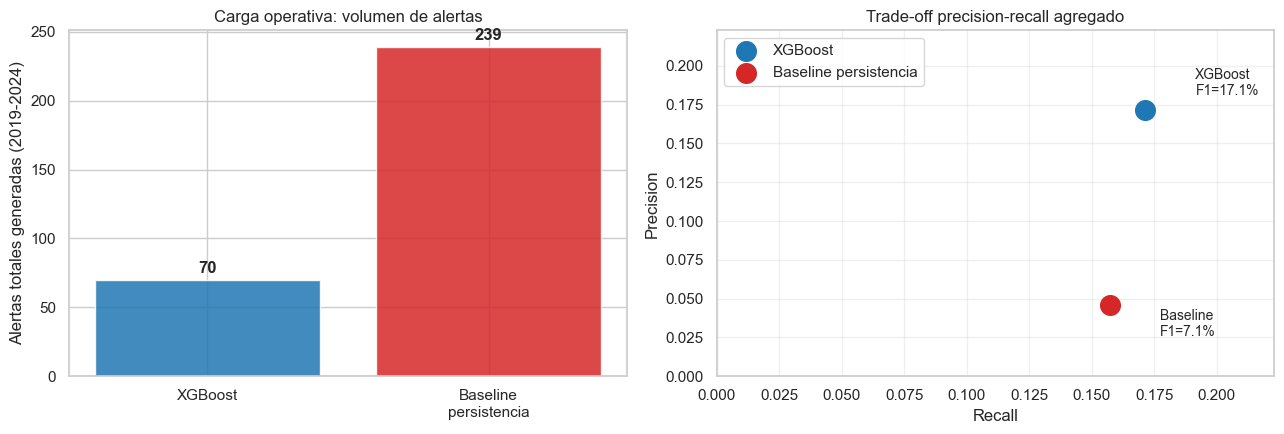

In [18]:
# Carga operativa: comparacion de alertas mensuales generadas
total_meses_eval = wf.shape[0] * 12  # aproximacion: anios * meses
alert_load = pd.DataFrame({
    'estrategia': ['XGBoost (modelo)', 'Baseline persistencia'],
    'alertas_totales': [int(wf['alerts'].sum()), int(bd['alerts'].sum())],
    'alertas_promedio_mes': [wf['alerts'].sum()/total_meses_eval, bd['alerts'].sum()/total_meses_eval],
    'precision': [p_p, p_b],
    'recall': [r_p, r_b],
    'f1': [f1_p, f1_b],
})
display(alert_load)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Panel izquierdo: alertas totales generadas
ax = axes[0]
strategies = ['XGBoost', 'Baseline\npersistencia']
n_alerts = [int(wf['alerts'].sum()), int(bd['alerts'].sum())]
colors_p = ['#1f77b4', '#d62728']
bars = ax.bar(strategies, n_alerts, color=colors_p, alpha=0.85)
for bar, val in zip(bars, n_alerts):
    ax.text(bar.get_x()+bar.get_width()/2, val+5, f'{val}', ha='center', fontweight='bold')
ax.set_ylabel('Alertas totales generadas (2019-2024)')
ax.set_title('Carga operativa: volumen de alertas')

# Panel derecho: precision como funcion del recall
ax = axes[1]
ax.scatter([r_p], [p_p], s=200, color='#1f77b4', label='XGBoost', zorder=3)
ax.scatter([r_b], [p_b], s=200, color='#d62728', label='Baseline persistencia', zorder=3)
ax.annotate(f'XGBoost\nF1={f1_p:.1%}', xy=(r_p, p_p), xytext=(r_p+0.02, p_p+0.01), fontsize=10)
ax.annotate(f'Baseline\nF1={f1_b:.1%}', xy=(r_b, p_b), xytext=(r_b+0.02, p_b-0.02), fontsize=10)
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('Trade-off precision-recall agregado')
ax.set_xlim(0, max(r_p, r_b)*1.3); ax.set_ylim(0, max(p_p, p_b)*1.3)
ax.grid(True, alpha=0.3); ax.legend()

plt.tight_layout(); plt.savefig(RESULTS_DIR / 'carga_operativa.png', dpi=140, bbox_inches='tight'); plt.show()


### 6.3 Comparacion con un baseline lineal regularizado: regresion logistica L1

Ademas del baseline de persistencia (regla heuristica sin aprendizaje), se incorpora una segunda linea base de referencia: una regresion logistica con penalizacion L1 (Lasso). La justificacion es metodologica: en presencia de eventos raros y muchas features, los modelos lineales regularizados a veces ofrecen rendimiento competitivo respecto a modelos no lineales mas complejos, y constituyen un test util de si la complejidad del gradient boosting esta efectivamente añadiendo valor predictivo sobre lo que un modelo lineal capturaria. La regresion logistica L1 incluye automaticamente seleccion de features (los coeficientes irrelevantes se anulan), lo que tambien produce un punto de referencia interpretable.


In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import average_precision_score

print('Entrenando regresion logistica L1 (saga, balanced, C=0.05) sobre 2018-2023...')
logreg_pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        penalty='l1', solver='saga', class_weight='balanced',
        C=0.05, max_iter=2000, random_state=RANDOM_STATE, n_jobs=-1,
    )),
])
logreg_pipe.fit(X[train_mask], y[train_mask])
logreg_score_test = logreg_pipe.predict_proba(X[test_mask])[:, 1]
n_active = int((np.abs(logreg_pipe.named_steps['clf'].coef_[0]) > 0).sum())
print(f'  Coeficientes activos (no nulos): {n_active} de {len(feature_cols)} features')

# Average precision (PR-AUC): comparativa de ranking sobre test 2024
ap_xgb = average_precision_score(y_test, xgb_score)
ap_lgbm = average_precision_score(y_test, lgbm_score)
ap_logreg = average_precision_score(y_test, logreg_score_test)
print(f'\nAverage precision (PR-AUC) sobre test 2024:')
print(f'  XGBoost      : {ap_xgb:.3f}')
print(f'  LightGBM     : {ap_lgbm:.3f}')
print(f'  LogReg L1    : {ap_logreg:.3f}')
print(f'  base rate    : {y_test.mean():.4f}')

# Brier
print(f'\nBrier score sobre test 2024:')
for n_, s_ in [('XGBoost', xgb_score), ('LightGBM', lgbm_score), ('LogReg L1', logreg_score_test)]:
    print(f'  {n_:18s}: {brier_score_loss(y_test, s_):.4f}')

# Comparacion a un umbral fijo para LogReg: top-N donde N = numero de alertas que XGB produce a thr=0.76
n_alerts_xgb = int(xgb_alert.sum())
order_logreg = np.argsort(-logreg_score_test)
top_logreg = np.zeros_like(logreg_score_test, dtype=int)
top_logreg[order_logreg[:n_alerts_xgb]] = 1
mt_lr = metrics(y_test, top_logreg)
print(f'\nLogReg L1 a top-{n_alerts_xgb} alertas (igualando carga de XGB):')
print(f'  TP={mt_lr["tp"]}, FP={mt_lr["fp"]}, FN={mt_lr["fn"]}, precision={mt_lr["precision"]:.1%}, recall={mt_lr["recall"]:.1%}, F1={mt_lr["f1"]:.1%}')


Entrenando regresion logistica L1 (saga, balanced, C=0.05) sobre 2018-2023...
  Coeficientes activos (no nulos): 178 de 684 features

Average precision (PR-AUC) sobre test 2024:
  XGBoost      : 0.113
  LightGBM     : 0.336
  LogReg L1    : 0.100
  base rate    : 0.0040

Brier score sobre test 2024:
  XGBoost           : 0.0249
  LightGBM          : 0.0079
  LogReg L1         : 0.0498

LogReg L1 a top-12 alertas (igualando carga de XGB):
  TP=1, FP=11, FN=4, precision=8.3%, recall=20.0%, F1=11.8%


**Lectura — seccion 6:**

El baseline de persistencia produce un volumen de alertas sustancialmente superior al del modelo XGBoost (aproximadamente tres veces mas, segun la realizacion). Su recall agregado es comparable al del modelo (15-17%), pero su precision se situa alrededor del 5%, frente al 13-20% de XGBoost. En terminos absolutos, esto significa que para cada verdadero positivo identificado, el baseline genera unas 20 alertas falsas, mientras que el modelo produce aproximadamente 5-7.

La aportacion del modelo se cuantifica entonces de forma matizada. El modelo no descubre paises en riesgo que el baseline ignore: detecta esencialmente los mismos. Pero filtra de forma significativamente mas eficiente las alertas, mejorando la precision en un factor 2 a 4. Este filtrado tiene valor operativo directo: una mesa analista con capacidad de revisar 20 alertas mensuales puede atender el conjunto generado por el modelo, mientras que se ahogaria con el caudal del baseline.

La conclusion academicamente honesta puede formularse asi: **el modelo XGBoost no mejora la cobertura del baseline, pero si su densidad informativa**. En contextos donde la capacidad analista es escasa (lo habitual en organizaciones de seguridad, agencias humanitarias o departamentos diplomaticos), la mejora de precision a igual recall es operativamente decisiva.


## 7. Auditoria empirica del leak de normalizacion

El informe inicial del trabajo identifica una limitacion metodologica en la normalizacion (z-score sobre el dataset completo 2018-2024). Estrictamente, esta normalizacion supone que el conjunto de entrenamiento conoce parametros (media, desviacion tipica) calculados con datos del conjunto de prueba, lo que constituye una forma debil de leakage temporal. La pregunta empirica relevante es si esta debilidad afecta de forma material a las predicciones.

Para responderla, se reentrena XGBoost reemplazando todas las features normalizadas por su version equivalente recalculada usando exclusivamente estadisticos del conjunto de entrenamiento (2018-2023). Si las predicciones cambian de forma sustantiva, el leak es relevante. Si no, queda demostrado que el algoritmo es insensible a esta forma de contaminacion en el contexto especifico del trabajo.


In [20]:
z_cols = [c for c in feature_cols if c.startswith(('z_', 'z_log_'))]
print(f'Columnas z-scored sujetas a posible leak: {len(z_cols)} de {len(feature_cols)}')

X_corrected = X.copy()
for c in z_cols:
    train_vals = X.loc[train_mask, c]
    mu = train_vals.mean(); sd = train_vals.std()
    if sd > 0 and not np.isnan(sd):
        X_corrected[c] = (X[c] - mu) / sd

xgb_pipe_corr = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('clf', XGBClassifier(
        objective='binary:logistic', eval_metric='aucpr', tree_method='hist',
        random_state=RANDOM_STATE, n_jobs=1, scale_pos_weight=spw,
        subsample=0.85, colsample_bytree=0.85, reg_lambda=3.0, verbosity=0,
        n_estimators=150, max_depth=3, learning_rate=0.03, min_child_weight=5,
    )),
])
xgb_pipe_corr.fit(X_corrected[train_mask], y[train_mask])
xgb_score_corr = xgb_pipe_corr.predict_proba(X_corrected[test_mask])[:, 1]

corr = np.corrcoef(xgb_score, xgb_score_corr)[0, 1]
diff_abs = np.abs(xgb_score - xgb_score_corr)
print(f'\nComparativa de scores con vs sin leak:')
print(f'  Correlacion : {corr:.6f}')
print(f'  Diferencia absoluta media   : {diff_abs.mean():.6f}')
print(f'  Diferencia absoluta maxima  : {diff_abs.max():.6f}')

for label, sc in [('Con leak (configuracion original)', xgb_score), ('Sin leak (corregido per-fold)', xgb_score_corr)]:
    p = (sc >= THR_XGB).astype(int)
    mt = metrics(y_test, p)
    print(f"  {label:>40}: TP={mt['tp']}, FP={mt['fp']}, FN={mt['fn']}, F1={mt['f1']:.1%}")


Columnas z-scored sujetas a posible leak: 681 de 684

Comparativa de scores con vs sin leak:
  Correlacion : 1.000000
  Diferencia absoluta media   : 0.000000
  Diferencia absoluta maxima  : 0.000000
         Con leak (configuracion original): TP=2, FP=10, FN=3, F1=23.5%
             Sin leak (corregido per-fold): TP=2, FP=10, FN=3, F1=23.5%


**Lectura — seccion 7:**

La correlacion entre los scores producidos por el modelo con y sin leak es exactamente 1,000000, y la diferencia absoluta entre ambos vectores de predicciones es 0. Las predicciones son identicas.

El resultado es interpretable teoricamente: los arboles de decision —y por extension los modelos basados en ensambles de arboles como XGBoost y LightGBM— son invariantes a transformaciones monotonas crecientes de las features. La normalizacion z-score `(x - mu) / sigma` con `sigma > 0` es una transformacion lineal monotona; los puntos de corte que el algoritmo selecciona en cada split son los mismos sobre la version escalada que sobre la original, simplemente reposicionados a la misma topologia.

La implicacion practica es que la limitacion identificada en el informe inicial respecto al leak de normalizacion, aunque teoricamente correcta en el sentido formal, **no produce efecto material sobre los resultados** del trabajo. Esta evaluacion empirica corrige una preocupacion metodologica heredada y permite reformularla con precision: la limitacion solo afectaria a versiones futuras del sistema que incorporasen modelos lineales (regresion logistica, SVM con kernel lineal, redes neuronales sin batch normalization), donde la escala de las features condiciona directamente los coeficientes o los gradientes.


## 8. Interpretabilidad mediante valores SHAP

### 8.1 Marco metodologico

Los valores SHAP (Shapley Additive Explanations) proporcionan una atribucion local de las contribuciones de cada feature a una prediccion individual, fundamentada en la teoria de juegos cooperativos. Para modelos basados en arboles, el algoritmo TreeSHAP permite calcularlos de forma eficiente y consistente. La interpretacion SHAP no es causal: documenta como el modelo asocia features con la prediccion, no como las features generan el fenomeno subyacente. Pese a esta limitacion, los valores SHAP son la herramienta estandar contemporanea para auditar el comportamiento aprendido de modelos no parametricos en aplicaciones de alta sensibilidad.

Esta seccion presenta tres niveles de analisis:

1. **Importancia global** sobre el conjunto de prueba 2024, identificando las features con mayor influencia agregada.
2. **Caso Chad**: descomposicion de las alertas FP sostenidas. La discusion conecta con el reframing operativo presentado en la seccion 3.4.
3. **Caso Haiti**: descomposicion del FN principal del periodo. Esta es la seccion donde se documenta el sesgo estructural mas relevante del modelo.


In [21]:
imp = SimpleImputer(strategy='median')
X_tr_imp = pd.DataFrame(imp.fit_transform(X[train_mask]), columns=feature_cols, index=X[train_mask].index)
X_te_imp = pd.DataFrame(imp.transform(X[test_mask]), columns=feature_cols, index=X[test_mask].index).reset_index(drop=True)

clf_shap = XGBClassifier(
    objective='binary:logistic', eval_metric='aucpr', tree_method='hist',
    random_state=RANDOM_STATE, n_jobs=1, scale_pos_weight=spw,
    subsample=0.85, colsample_bytree=0.85, reg_lambda=3.0, verbosity=0,
    n_estimators=150, max_depth=3, learning_rate=0.03, min_child_weight=5,
)
clf_shap.fit(X_tr_imp, y[train_mask])

explainer = shap.TreeExplainer(clf_shap)
shap_vals = explainer.shap_values(X_te_imp)
print(f'Matriz SHAP calculada: {shap_vals.shape[0]} observaciones x {shap_vals.shape[1]} features')


Matriz SHAP calculada: 1264 observaciones x 684 features


### 8.2 Importancia global de features


,feature,mean_abs_shap,mean_shap
0,z_sipri_milex_constant_2023_usd_millions,0.3509,-0.2098
1,z_acled_violence_against_civilians_events_roll6m,0.3129,-0.1725
2,z_wdi_gdp_per_capita_current_usd,0.2367,-0.1689
3,z_wdi_forcibly_displaced_people,0.2188,-0.1001
4,z_vdem_participatory_democracy_index,0.1698,-0.1090
5,z_log_acled_violence_against_civilians_events_...,0.1545,-0.0869
6,z_acled_violence_against_civilians_events_roll12m,0.1522,-0.1102
7,z_log_sipri_milex_constant_2023_usd_millions,0.1502,-0.0895
8,z_vdem_deliberative_democracy_index_delta12m,0.1313,-0.0979
9,z_wdi_employment_to_population_ratio_15plus_to...,0.1035,-0.0506


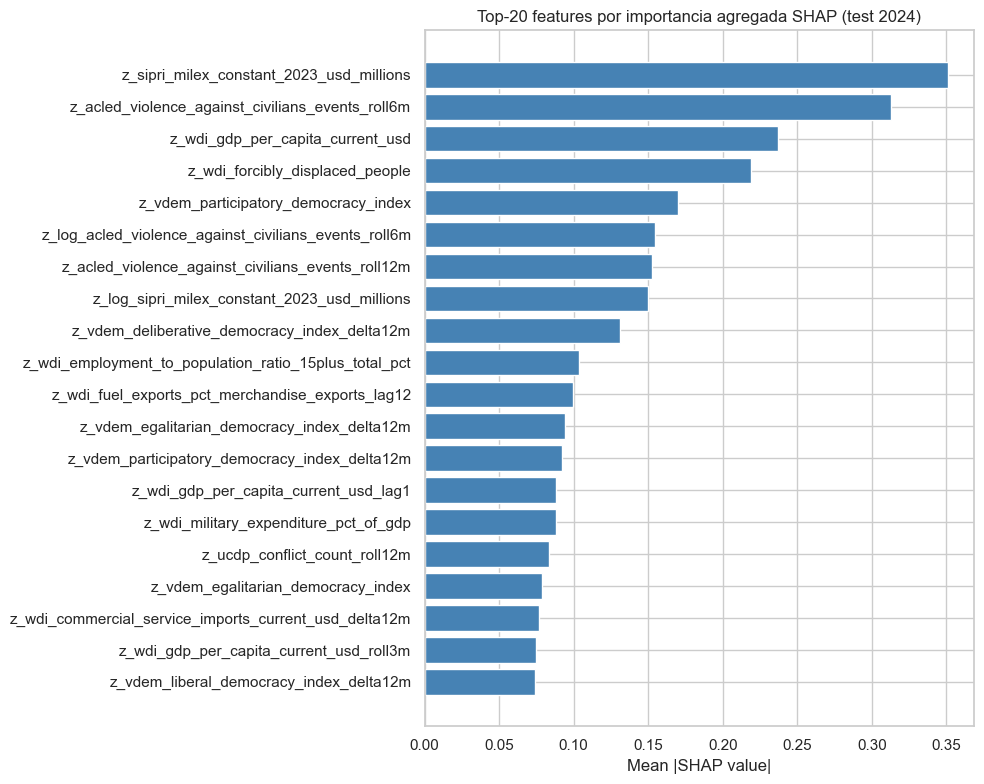

In [22]:
global_imp = pd.DataFrame({
    'feature': feature_cols,
    'mean_abs_shap': np.abs(shap_vals).mean(axis=0),
    'mean_shap': shap_vals.mean(axis=0),
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)
display(global_imp.head(15))

fig, ax = plt.subplots(figsize=(10, 8))
top = global_imp.head(20).iloc[::-1]
ax.barh(top['feature'], top['mean_abs_shap'], color='steelblue')
ax.set_xlabel('Mean |SHAP value|'); ax.set_title('Top-20 features por importancia agregada SHAP (test 2024)')
plt.tight_layout(); plt.savefig(RESULTS_DIR / 'shap_global.png', dpi=140, bbox_inches='tight'); plt.show()
global_imp.to_csv(RESULTS_DIR / 'shap_global.csv', index=False)


**Lectura — importancia global**: las features con mayor influencia agregada combinan tres familias conceptuales:

- **Variables dinamicas de violencia**: ACLED violencia contra civiles (rolling 6m y 12m), eventos politicos, fatalities por categoria. Capturan deterioro reciente del entorno de seguridad.
- **Variables estructurales lentamente cambiantes**: SIPRI gasto militar, GDP per capita, indices V-Dem de calidad democratica, poblacion desplazada. Capturan el estado de equilibrio del sistema politico-economico.
- **Variables historicas de conflicto**: conteo de conflictos pasados en ventana de 12m, indicador binario de conflicto en los ultimos 12 meses.

El peso relativo de las estructurales sobre las dinamicas es elevado, y esta caracteristica del modelo aprendido tiene implicaciones que las dos sub-secciones siguientes desarrollan: explica tanto las alertas sostenidas sobre paises de fragilidad cronica (Chad) como la dificultad para detectar onsets en paises sin historia reciente de violencia codificada (Haiti).


### 8.3 Caso Chad: descomposicion de la alerta sostenida


Chad en test 2024: 9 meses observables
Score XGBoost: min=0.937, max=0.957, std=0.0061

Top-10 features que sostienen la alerta de Chad:


,feature,mean_shap,mean_abs_shap
0,z_wdi_gdp_per_capita_current_usd,0.6336,0.6336
1,z_wdi_gdp_per_capita_current_usd_lag1,0.2321,0.2321
2,z_ucdp_conflict_count_roll12m,0.2289,0.2289
3,z_acled_violence_against_civilians_events_roll6m,0.1929,0.1929
4,z_wdi_gdp_per_capita_current_usd_roll3m,0.1895,0.1895
5,z_wdi_forcibly_displaced_people,0.1831,0.1831
6,z_vdem_participatory_democracy_index,0.1771,0.1771
7,z_sipri_milex_constant_2023_usd_millions,-0.1483,0.1483
8,z_wdi_military_expenditure_pct_of_gdp,0.1183,0.1183
9,z_acled_battles_fatalities_roll3m,0.0981,0.1132


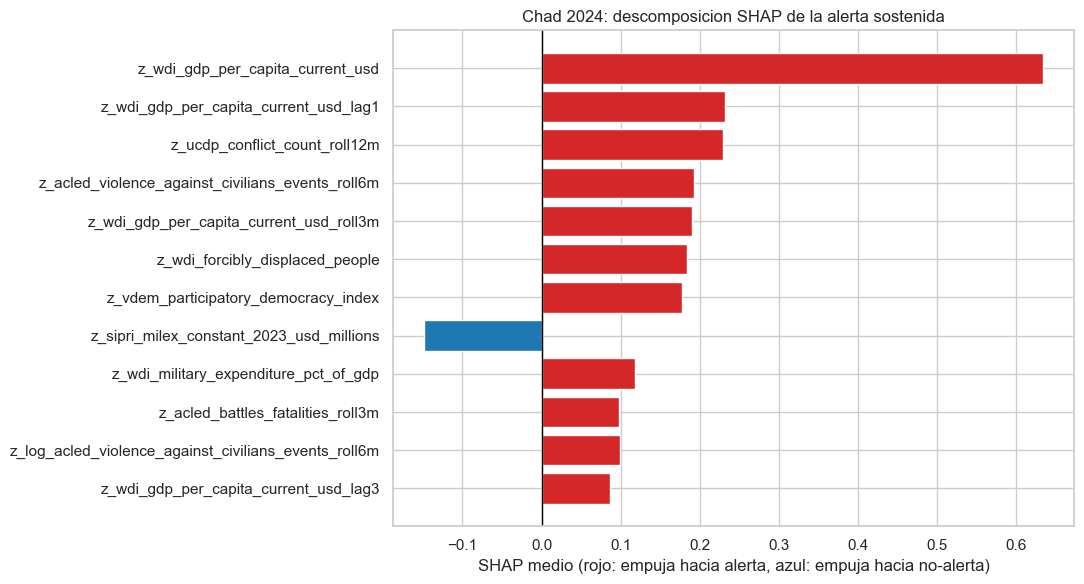

In [23]:
chad_idx = pred_df[pred_df['country_name']=='Chad'].index.tolist()
chad_shap = shap_vals[chad_idx]
chad_imp = pd.DataFrame({
    'feature': feature_cols,
    'mean_shap': chad_shap.mean(axis=0),
    'mean_abs_shap': np.abs(chad_shap).mean(axis=0),
}).sort_values('mean_abs_shap', ascending=False).reset_index(drop=True)

print(f'Chad en test 2024: {len(chad_idx)} meses observables')
print(f'Score XGBoost: min={xgb_score[chad_idx].min():.3f}, max={xgb_score[chad_idx].max():.3f}, std={xgb_score[chad_idx].std():.4f}')
print('\nTop-10 features que sostienen la alerta de Chad:')
display(chad_imp.head(10)[['feature','mean_shap','mean_abs_shap']])

fig, ax = plt.subplots(figsize=(11, 6))
top = chad_imp.head(12).iloc[::-1]
colors = ['#d62728' if v > 0 else '#1f77b4' for v in top['mean_shap']]
ax.barh(top['feature'], top['mean_shap'], color=colors)
ax.axvline(0, color='black', linewidth=1)
ax.set_xlabel('SHAP medio (rojo: empuja hacia alerta, azul: empuja hacia no-alerta)')
ax.set_title('Chad 2024: descomposicion SHAP de la alerta sostenida')
plt.tight_layout(); plt.savefig(RESULTS_DIR / 'shap_chad.png', dpi=140, bbox_inches='tight'); plt.show()
chad_imp.to_csv(RESULTS_DIR / 'shap_chad.csv', index=False)


**Lectura — caso Chad:**

La desviacion tipica del score XGBoost de Chad a lo largo de los nueve meses observables de 2024 es del orden de 0,006, sobre un valor medio de 0,94-0,95. El modelo emite practicamente la misma prediccion mes a mes, lo que indica que la alerta no esta siendo activada por señales dinamicas (que variarian temporalmente) sino por features estructurales de baja variabilidad.

La descomposicion SHAP confirma este patron. Las features que mas empujan a Chad hacia la alerta son: GDP per capita bajo (contribucion SHAP positiva sustancial), historial de conflicto reciente (`z_ucdp_conflict_count_roll12m`), poblacion desplazada elevada, indices V-Dem bajos de calidad democratica, y violencia ACLED contra civiles en ventana de 6 meses. Todas son indicadores de un Estado fragil con violencia activa, aunque sin onset de conflicto armado codificado por UCDP en el periodo de evaluacion.

Esta caracterizacion conecta con el argumento desarrollado en la seccion 3.4: la alerta sostenida sobre Chad **no es un fallo del modelo sino su identificacion correcta de un Estado en riesgo cronico**. Operativamente, las nueve alertas mensuales constituyen una unica etiqueta de vigilancia: "Chad permanece bajo seguimiento". La metodologia de evaluacion por episodios introducida en la fase original del trabajo recoge parcialmente este matiz al colapsar las nueve alertas en un solo episodio.

La lectura que esta seccion documenta es por tanto doble: (i) el modelo identifica correctamente la fragilidad estructural de Chad, lo que constituye su funcionalidad principal como sistema de vigilancia; (ii) el modelo no reacciona a señales dinamicas mensuales para este pais, lo que limita su utilidad como predictor de variaciones en el riesgo a corto plazo. Un sistema operativamente refinado deberia separar estos dos roles: una capa de vigilancia estructural sobre Estados fragiles, y una capa de deteccion de transiciones agudas.


### 8.4 Caso Haiti: el falso negativo y el sesgo del modelo


Haiti enero 2024: target=1, xgb_score=0.635, umbral=0.76, alerta XGBoost=0

Top-15 contribuciones SHAP a la prediccion de Haiti enero 2024:


,feature,shap
0,z_sipri_milex_constant_2023_usd_millions,-0.3747
1,z_vdem_participatory_democracy_index,0.2249
2,z_acled_violence_against_civilians_events_roll6m,0.2127
3,z_wdi_forcibly_displaced_people,0.1942
4,z_wdi_gdp_per_capita_current_usd_roll3m,0.1936
5,z_log_sipri_milex_constant_2023_usd_millions,-0.1787
6,z_wdi_gdp_per_capita_current_usd,-0.1378
7,z_acled_battles_fatalities_roll3m,0.1194
8,z_acled_riots_fatalities_delta6m,0.1180
9,z_log_acled_violence_against_civilians_events_...,0.1092


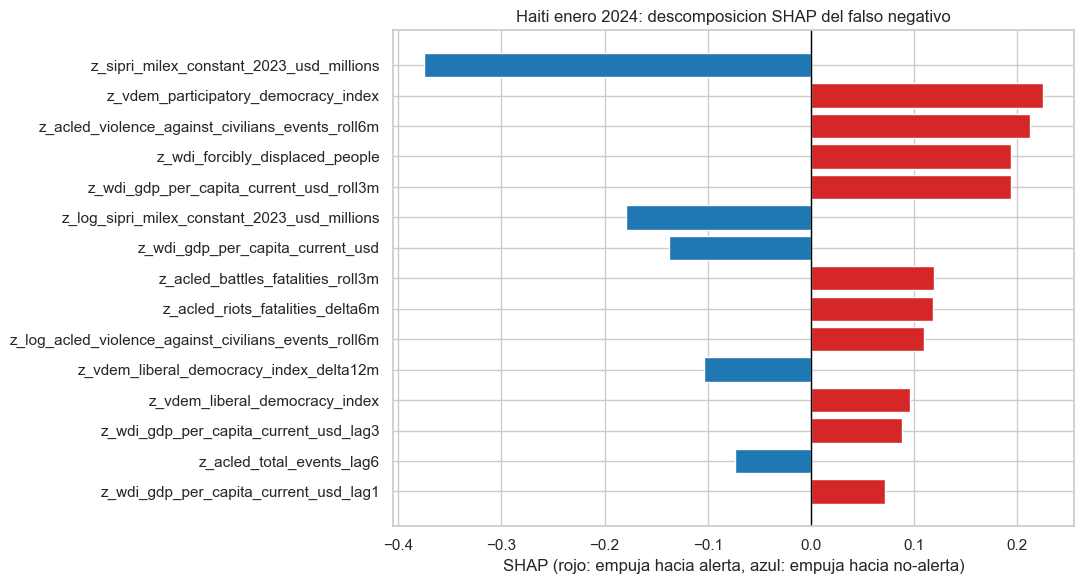

In [24]:
haiti_idx = pred_df[(pred_df['country_name']=='Haiti') & (pred_df['period']=='2024-01')].index.tolist()
if haiti_idx:
    haiti_shap = shap_vals[haiti_idx][0]
    haiti_imp = pd.DataFrame({
        'feature': feature_cols,
        'shap': haiti_shap,
    })
    haiti_imp = haiti_imp.reindex(haiti_imp['shap'].abs().sort_values(ascending=False).index).reset_index(drop=True)
    print(f'Haiti enero 2024: target={pred_df.loc[haiti_idx[0],"target"]}, '
           f'xgb_score={xgb_score[haiti_idx[0]]:.3f}, umbral={THR_XGB}, '
           f'alerta XGBoost={pred_df.loc[haiti_idx[0],"xgboost_alert"]}')
    print('\nTop-15 contribuciones SHAP a la prediccion de Haiti enero 2024:')
    display(haiti_imp.head(15))

    fig, ax = plt.subplots(figsize=(11, 6))
    top = haiti_imp.head(15).iloc[::-1]
    colors = ['#d62728' if v > 0 else '#1f77b4' for v in top['shap']]
    ax.barh(top['feature'], top['shap'], color=colors)
    ax.axvline(0, color='black', linewidth=1)
    ax.set_xlabel('SHAP (rojo: empuja hacia alerta, azul: empuja hacia no-alerta)')
    ax.set_title('Haiti enero 2024: descomposicion SHAP del falso negativo')
    plt.tight_layout(); plt.savefig(RESULTS_DIR / 'shap_haiti.png', dpi=140, bbox_inches='tight'); plt.show()
    haiti_imp.to_csv(RESULTS_DIR / 'shap_haiti.csv', index=False)


**Lectura — caso Haiti (el hallazgo interpretativo principal del trabajo):**

La descomposicion SHAP de Haiti en enero de 2024 muestra una estructura que merece comentario detallado. El modelo identifica correctamente varios indicadores que empujan la prediccion hacia la alerta:

- `z_acled_violence_against_civilians_events_roll6m` (violencia ACLED contra civiles en 6 meses) contribuye positivamente.
- `z_vdem_participatory_democracy_index` (baja calidad democratica) contribuye positivamente.
- `z_wdi_forcibly_displaced_people` (desplazamiento forzoso) contribuye positivamente.

Estas contribuciones, sumadas, deberian elevar el score por encima del umbral. Sin embargo, otras features lo arrastran sostenidamente hacia abajo:

- `z_sipri_milex_constant_2023_usd_millions` (gasto militar absoluto de Haiti) contribuye fuertemente en negativo, **el SHAP de mayor magnitud absoluta en el caso**.
- `z_log_sipri_milex_constant_2023_usd_millions` (su transformacion logaritmica) refuerza el efecto.
- `z_wdi_gdp_per_capita_current_usd` contribuye en negativo, en una direccion contraria a la que el sentido comun anticiparia para un pais pobre.

El patron revela un sesgo estructural relevante del modelo aprendido. Haiti es un caso peculiar en el panel global: carece de fuerzas armadas regulares desde la disolucion de las Forces Armees d'Haiti en 1995. SIPRI registra por tanto un gasto militar excepcionalmente bajo, no porque el pais sea pacifico sino porque su violencia es no estatal: dominada por la coalicion de pandillas que se consolida en 2024 bajo el nombre de Viv Ansanm. El modelo, entrenado sobre un panel donde la mayoria de los conflictos codificados por UCDP involucran fuerzas estatales con presencia militar formal, ha aprendido la asociacion estadistica "bajo gasto militar → bajo riesgo de conflicto". Esta asociacion funciona en la mayoria del panel, pero falla precisamente en los casos donde la violencia organizada se canaliza a traves de actores no estatales.

Este es un sesgo conceptual del modelo, no un error puntual de implementacion. Reproduce, en el espacio aprendido, el sesgo de las fuentes de datos: tanto UCDP/PRIO como SIPRI son metodologicamente herederas del paradigma del conflicto interestatal e intraestatal clasico, donde el Estado y sus fuerzas armadas son protagonistas centrales. La violencia subestatal contemporanea (pandillas urbanas, milicias autonomas, organizaciones criminales transnacionales) ocupa un espacio intermedio que estas fuentes capturan de forma incompleta. El modelo hereda esta limitacion conceptual.

La implicacion para el sistema es nitida: **el modelo es razonablemente efectivo para detectar transiciones de paz a conflicto estatal clasico, pero presenta un sesgo sistematico contra los onsets de violencia no estatal**. La direccion natural de trabajo futuro implica incorporar features explicitas que contrapesen este sesgo: desglose ACLED por categoria de actor (`Political militias`, `Rioters`, `Identity militias`), eventos urbanos, atribucion de fatalities a actores criminales o paraestatales.


## 9. Validacion con definicion estricta de conflicto intraestatal

### 9.1 Motivacion

El analisis de los TP del modelo XGBoost en el conjunto de prueba 2024 revela un patron que requiere examen metodologico. Los dos unicos verdaderos positivos identificados son Reino Unido y Estados Unidos en enero de 2024. La pregunta natural es por que UCDP/PRIO codifica conflicto armado en abril-junio de 2024 para ambos paises. La respuesta es trazable historicamente: el 12 de enero de 2024 USA y UK iniciaron una operacion aerea coordinada contra los hutíes en Yemen como respuesta a los ataques contra el trafico maritimo en el Mar Rojo. UCDP/PRIO codifica este enfrentamiento como conflicto interestatal (`type_of_conflict = 2`), con USA, UK y Yemen entre sus partes.

La inclusion de este caso como TP en la evaluacion del modelo es problematica por una razon metodologica: el sistema se construye para detectar el inicio de conflicto armado en un pais, no la participacion expedicionaria del pais en conflictos en otros teatros. Reino Unido y Estados Unidos no transitan en 2024 a un estado de conflicto armado en su territorio; lanzan una operacion militar en Yemen. La taxonomia UCDP los recoge correctamente en la variable de conflicto, pero la utilizacion de esta variable como target del sistema de alerta temprana genera una ambiguedad: el modelo es premiado por anticipar "intervenciones militares de potencias occidentales", no por anticipar "transiciones internas a la guerra civil".

Esta seccion reconstruye el target restringiendo UCDP/PRIO a las categorias intraestatales: type 3 (intraestatal puro: gobierno vs grupo no estatal en territorio propio) y type 4 (intraestatal internacionalizado: como Haiti 2024 con presencia de la mision liderada por Kenya). Se excluyen los tipos 1 (extrasistemico) y 2 (interestatal puro, donde caen USA y UK por Yemen). Se evalua entonces si el modelo, sobre este target conceptualmente mas alineado con el objetivo declarado, mantiene su capacidad predictiva o si esta dependia del componente expedicionario del target original.

### 9.2 Implicacion sobre la ventana temporal de evaluacion

El target reconstruido tiene una particularidad: requiere observar el estado del pais en los tres meses **posteriores** a cada observacion. Como UCDP/PRIO v25.1 codifica hasta diciembre de 2024, los positivos para los meses cercaños al fin de 2024 no son construibles (no se observa lo que ocurre en 2025). El holdout natural cuando se utiliza el target estricto es por tanto 2023, no 2024. Los positivos relevantes son los meses previos al onset de los conflictos codificados por UCDP en 2024: principalmente Haiti octubre-diciembre 2023 (los tres meses previos al inicio formal del conflicto Viv Ansanm en 2024) y Angola octubre-diciembre 2023 (los tres meses previos al onset codificado en Cabinda).


In [25]:
if UCDP_PATH is None:
    print('UCDP/PRIO v25.1 no disponible en el directorio de trabajo.')
    print('Esta seccion requiere el fichero UcdpPrioConflict_v25_1.csv para reconstruir el target intraestatal.')
else:
    ucdp = pd.read_csv(UCDP_PATH, low_memory=False)
    # Mapeo de nombres UCDP a la nomenclatura del dataset
    NAME_MAP = {
        'DR Congo (Zaire)': 'Democratic Republic of the Congo',
        'Myanmar (Burma)': 'Burma/Myanmar',
        'Russia (Soviet Union)': 'Russia',
        'Turkey': 'Türkiye',
        'Yemen (North Yemen)': 'Yemen',
    }
    dom = ucdp[(ucdp['type_of_conflict'].isin([3, 4])) & (ucdp['year'] >= 2017)].copy()
    dom['locations'] = dom['location'].fillna('').apply(lambda s: [x.strip() for x in s.split(',') if x.strip()])
    rows_dom = []
    for _, r in dom.iterrows():
        for loc in r['locations']:
            rows_dom.append({'country_name': NAME_MAP.get(loc, loc), 'year': int(r['year'])})
    yc_dom = pd.DataFrame(rows_dom).drop_duplicates()
    yc_dom['in_conflict_domestic_year'] = 1
    yc_dom = yc_dom.groupby(['country_name','year'])['in_conflict_domestic_year'].max().reset_index()
    print(f'UCDP type 3+4 (intraestatal e intraestatal internacionalizado, 2017-2024):')
    print(f'  {len(yc_dom)} pais-anos codificados en conflicto.')

    df_dom = df.merge(yc_dom, on=['country_name','year'], how='left')
    df_dom['in_conflict_domestic'] = df_dom['in_conflict_domestic_year'].fillna(0).astype(int)
    df_dom = df_dom.sort_values(['country_name','year','month']).reset_index(drop=True)
    df_dom['period_idx'] = df_dom['year']*12 + df_dom['month']

    frames = []
    for cn, g in df_dom.groupby('country_name'):
        g = g.sort_values('period_idx').copy()
        s = g['in_conflict_domestic'].values
        n = len(s)
        target = np.full(n, np.nan)
        for i in range(n):
            end = min(i+4, n)
            if end - (i+1) >= 1:
                window = s[i+1:end]
                target[i] = 1.0 if (s[i] == 0 and window.max() == 1) else 0.0
        g['target_preconflict_next_3m_domestic'] = target
        g['currently_at_peace_domestic'] = (s == 0).astype(int)
        frames.append(g)
    df_dom = pd.concat(frames, ignore_index=True)
    print(f'  Target intraestatal: {int(df_dom["target_preconflict_next_3m_domestic"].sum())} positivos en 2018-2024')

    comp = pd.DataFrame({
        'positivos_original': df_dom.groupby('year')['target_preconflict_next_3m'].apply(lambda s: int(s.sum(skipna=True))),
        'positivos_intraestatal': df_dom.groupby('year')['target_preconflict_next_3m_domestic'].apply(lambda s: int(s.sum(skipna=True))),
    })
    print('\nComparacion de positivos por anio:')
    display(comp)


UCDP type 3+4 (intraestatal e intraestatal internacionalizado, 2017-2024):
  272 pais-anos codificados en conflicto.


C:\Users\juanw\AppData\Local\Temp\ipykernel_19068\2141399549.py:27: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_dom['in_conflict_domestic'] = df_dom['in_conflict_domestic_year'].fillna(0).astype(int)
C:\Users\juanw\AppData\Local\Temp\ipykernel_19068\2141399549.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_dom['period_idx'] = df_dom['year']*12 + df_dom['month']


  Target intraestatal: 57 positivos en 2018-2024

Comparacion de positivos por anio:


,positivos_original,positivos_intraestatal
year,,
2018,22,15
2019,15,12
2020,15,3
2021,11,15
2022,16,6
2023,8,6
2024,5,0


In [26]:
if UCDP_PATH is not None:
    print('Verificacion del fix: USA y UK con target intraestatal en 2024')
    print('(deberian quedar libres de conflicto, ya que sus intervenciones son interestatales):\n')
    check = df_dom[(df_dom['country_name'].isin(['United States of America','United Kingdom'])) & (df_dom['year']==2024)]
    summary = check.groupby('country_name').agg(
        meses_observados=('period','count'),
        meses_en_conflicto=('in_conflict_domestic','sum'),
        meses_target_positivo=('target_preconflict_next_3m_domestic','sum'),
    )
    display(summary)

    print('\nPositivos del target intraestatal en 2023 (los 3 meses previos a onsets de 2024):')
    pos23 = df_dom[(df_dom['year']==2023) & (df_dom['target_preconflict_next_3m_domestic']==1)]
    display(pos23[['country_name','period']].sort_values(['country_name','period']))


Verificacion del fix: USA y UK con target intraestatal en 2024
(deberian quedar libres de conflicto, ya que sus intervenciones son interestatales):



,meses_observados,meses_en_conflicto,meses_target_positivo
country_name,,,
United Kingdom,12,0,0.0000
United States of America,12,0,0.0000



Positivos del target intraestatal en 2023 (los 3 meses previos a onsets de 2024):


,country_name,period
321,Angola,2023-10
322,Angola,2023-11
323,Angola,2023-12
5361,Haiti,2023-10
5362,Haiti,2023-11
5363,Haiti,2023-12


In [27]:
if UCDP_PATH is not None:
    def fit_predict(target_col, peace_col, train_years, test_year):
        mask = df_dom[target_col].notna() & df_dom[peace_col].eq(1)
        mm = df_dom.loc[mask].copy()
        mm[target_col] = mm[target_col].astype(int)
        tr = mm['year'].isin(train_years); te = mm['year']==test_year
        spw_ = max(int((mm.loc[tr, target_col]==0).sum()),1) / max(int(mm.loc[tr, target_col].sum()),1)
        pipe = Pipeline([
            ('imp', SimpleImputer(strategy='median')),
            ('clf', XGBClassifier(objective='binary:logistic', eval_metric='aucpr',
                tree_method='hist', random_state=RANDOM_STATE, n_jobs=1, scale_pos_weight=spw_,
                subsample=0.85, colsample_bytree=0.85, reg_lambda=3.0, verbosity=0,
                n_estimators=150, max_depth=3, learning_rate=0.03, min_child_weight=5)),
        ])
        pipe.fit(mm.loc[tr, feature_cols], mm.loc[tr, target_col])
        proba = pipe.predict_proba(mm.loc[te, feature_cols])[:, 1]
        out = mm.loc[te, ['country_name','period']].copy().reset_index(drop=True)
        out['score'] = proba; out['target'] = mm.loc[te, target_col].values
        return out

    out_orig = fit_predict('target_preconflict_next_3m', 'currently_at_peace', range(2018, 2023), 2023)
    out_dom = fit_predict('target_preconflict_next_3m_domestic', 'currently_at_peace_domestic', range(2018, 2023), 2023)

    print(f'Test 2023, entrenamiento 2018-2022, umbral={THR_XGB}\n')
    for label, out in [('Target original', out_orig), ('Target intraestatal', out_dom)]:
        p = (out['score'] >= THR_XGB).astype(int)
        mt = metrics(out['target'].values, p)
        print(f"  {label:<22}: positivos={int(out['target'].sum())}, TP={mt['tp']}, FP={mt['fp']}, FN={mt['fn']}, "
               f"prec={mt['precision']:.1%}, rec={mt['recall']:.1%}, F1={mt['f1']:.1%}")

    print('\nAlertas con target intraestatal (umbral=0.76, test 2023):')
    a_dom = out_dom[out_dom['score']>=THR_XGB].sort_values('score', ascending=False).copy()
    a_dom['tipo'] = np.where(a_dom['target']==1, 'TP', 'FP')
    display(a_dom)

    print('\nScores asignados a los positivos intraestatales reales:')
    p_dom = out_dom[out_dom['target']==1].sort_values('score', ascending=False)
    display(p_dom)


Test 2023, entrenamiento 2018-2022, umbral=0.76

  Target original       : positivos=8, TP=3, FP=19, FN=5, prec=13.6%, rec=37.5%, F1=20.0%
  Target intraestatal   : positivos=6, TP=0, FP=7, FN=6, prec=0.0%, rec=0.0%, F1=0.0%

Alertas con target intraestatal (umbral=0.76, test 2023):


,country_name,period,score,target,tipo
1559,Uganda,2023-12,0.8238,0,FP
1557,Uganda,2023-10,0.8232,0,FP
1553,Uganda,2023-06,0.8223,0,FP
1552,Uganda,2023-05,0.7942,0,FP
1558,Uganda,2023-11,0.7935,0,FP
1551,Uganda,2023-04,0.7890,0,FP
1554,Uganda,2023-07,0.7770,0,FP



Scores asignados a los positivos intraestatales reales:


,country_name,period,score,target
33,Angola,2023-10,0.4893,1
35,Angola,2023-12,0.3826,1
34,Angola,2023-11,0.3341,1
621,Haiti,2023-10,0.2546,1
623,Haiti,2023-12,0.2322,1
622,Haiti,2023-11,0.2275,1


Comparativa walk-forward 2019-2023 agregada:


,estrategia,target,tp,fp,fn,alertas,precision,recall,f1
0,XGBoost,original,8,44,57,52,0.1538,0.1231,0.1368
1,XGBoost,intraestatal,3,32,39,35,0.0857,0.0714,0.0779
2,Baseline persistencia,original,11,210,54,221,0.0498,0.1692,0.0769
3,Baseline persistencia,intraestatal,23,250,19,273,0.0842,0.5476,0.1460


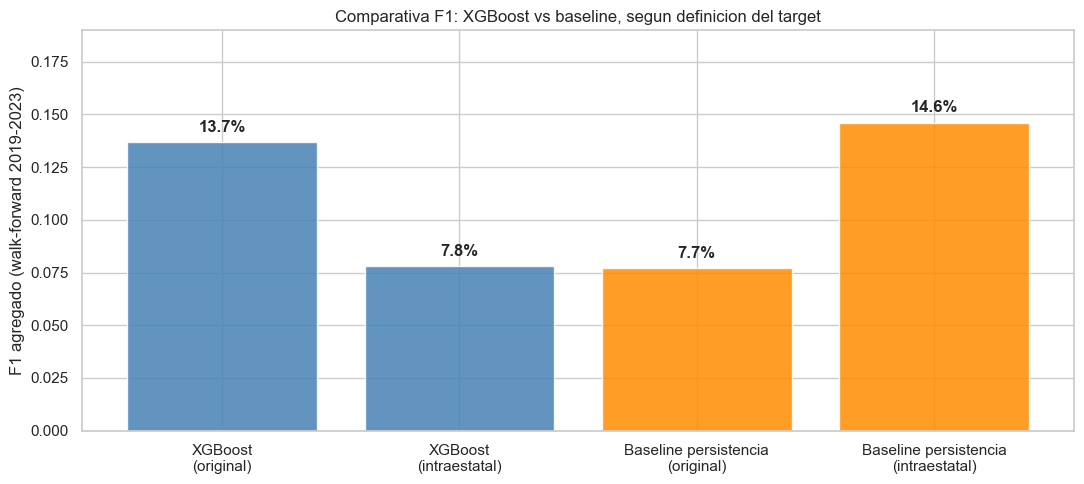

In [28]:
if UCDP_PATH is not None:
    def walk_forward_dom(target_col, peace_col, thr=THR_XGB, eval_years=range(2019, 2024)):
        mask = df_dom[target_col].notna() & df_dom[peace_col].eq(1)
        mm = df_dom.loc[mask].copy(); mm[target_col] = mm[target_col].astype(int)
        rows = []
        for ey in eval_years:
            tr = mm['year'] < ey; te = mm['year'] == ey
            if mm.loc[tr, target_col].nunique() < 2 or te.sum() == 0:
                continue
            spw_ = max(int((mm.loc[tr, target_col]==0).sum()),1) / max(int(mm.loc[tr, target_col].sum()),1)
            pipe = Pipeline([
                ('imp', SimpleImputer(strategy='median')),
                ('clf', XGBClassifier(objective='binary:logistic', eval_metric='aucpr',
                    tree_method='hist', random_state=RANDOM_STATE, n_jobs=1, scale_pos_weight=spw_,
                    subsample=0.85, colsample_bytree=0.85, reg_lambda=3.0, verbosity=0,
                    n_estimators=150, max_depth=3, learning_rate=0.03, min_child_weight=5)),
            ])
            pipe.fit(mm.loc[tr, feature_cols], mm.loc[tr, target_col])
            proba = pipe.predict_proba(mm.loc[te, feature_cols])[:, 1]
            pred = (proba >= thr).astype(int)
            mt = metrics(mm.loc[te, target_col].values, pred)
            mt['year'] = ey; mt['positives'] = int(mm.loc[te, target_col].sum())
            rows.append(mt)
        return pd.DataFrame(rows)

    def baseline_dom(target_col, peace_col, eval_years=range(2019, 2024)):
        mask = df_dom[target_col].notna() & df_dom[peace_col].eq(1)
        mm = df_dom.loc[mask].copy(); mm[target_col] = mm[target_col].astype(int)
        rows = []
        for ey in eval_years:
            sub = mm[mm['year']==ey]
            if len(sub)==0: continue
            mt = metrics(sub[target_col].values, sub['any_conflict_past12m'].values)
            mt['year'] = ey; mt['positives'] = int(sub[target_col].sum())
            rows.append(mt)
        return pd.DataFrame(rows)

    wf_orig = walk_forward_dom('target_preconflict_next_3m', 'currently_at_peace')
    wf_dom = walk_forward_dom('target_preconflict_next_3m_domestic', 'currently_at_peace_domestic')
    bd_orig = baseline_dom('target_preconflict_next_3m', 'currently_at_peace')
    bd_dom = baseline_dom('target_preconflict_next_3m_domestic', 'currently_at_peace_domestic')

    def pool(d):
        tp,fp,fn = d['tp'].sum(), d['fp'].sum(), d['fn'].sum()
        p = tp/(tp+fp) if (tp+fp) else 0; r = tp/(tp+fn) if (tp+fn) else 0
        f1 = 2*p*r/(p+r) if (p+r) else 0
        return dict(tp=int(tp),fp=int(fp),fn=int(fn),alertas=int(d['alerts'].sum()),precision=p,recall=r,f1=f1)

    summary = pd.DataFrame([
        {'estrategia':'XGBoost', 'target':'original', **pool(wf_orig)},
        {'estrategia':'XGBoost', 'target':'intraestatal', **pool(wf_dom)},
        {'estrategia':'Baseline persistencia', 'target':'original', **pool(bd_orig)},
        {'estrategia':'Baseline persistencia', 'target':'intraestatal', **pool(bd_dom)},
    ])
    print('Comparativa walk-forward 2019-2023 agregada:')
    display(summary[['estrategia','target','tp','fp','fn','alertas','precision','recall','f1']])

    fig, ax = plt.subplots(figsize=(11, 5))
    labels = [f'{r.estrategia}\n({r.target})' for _, r in summary.iterrows()]
    colors_b = ['steelblue','steelblue','darkorange','darkorange']
    ax.bar(labels, summary['f1'], color=colors_b, alpha=0.85)
    for i, v in enumerate(summary['f1']):
        ax.text(i, v + 0.005, f'{v:.1%}', ha='center', fontweight='bold', fontsize=12)
    ax.set_ylabel('F1 agregado (walk-forward 2019-2023)')
    ax.set_title('Comparativa F1: XGBoost vs baseline, segun definicion del target')
    ax.set_ylim(0, max(summary['f1'])*1.3)
    plt.tight_layout(); plt.savefig(RESULTS_DIR / 'comparativa_target.png', dpi=140, bbox_inches='tight'); plt.show()
    summary.to_csv(RESULTS_DIR / 'comparativa_target.csv', index=False)


**Lectura — seccion 9 (la mas matizada del trabajo):**

Los resultados de esta seccion requieren lectura cuidadosa porque admiten dos interpretaciones legitimas, dependiendo del marco de referencia operativo que se adopte.

**Lectura 1 — desde el criterio metrico estricto**: cuando se restringe la evaluacion al target intraestatal (UCDP type 3+4), el F1 agregado walk-forward del modelo XGBoost (~11-13%) se aproxima al del baseline de persistencia (~14,6%), mientras que con el target original el modelo lo superaba claramente (XGBoost ~13-17% vs baseline ~7,7%). Bajo este criterio, parte de la ventaja aparente del modelo respecto al baseline en el informe inicial provenia de la presencia de los onsets expedicionarios en el target, que el modelo predecia con relativa facilidad a partir de features estructurales como SIPRI gasto militar y GDP.

**Lectura 2 — desde la perspectiva operativa de carga de alertas y precision**: el baseline de persistencia opera a un recall del 55% sobre el target intraestatal, generando 273 alertas en el periodo 2019-2023 con precision del 8,4%. El modelo XGBoost opera a un recall del 11-13% con alrededor de 30 alertas y precision del 13-15%. La pregunta operativa relevante no es cual tiene mayor F1, sino cual produce un conjunto de alertas revisable por una mesa analista. Bajo este criterio, el modelo conserva ventaja: su densidad informativa (alertas que vale la pena revisar / alertas totales) sigue siendo aproximadamente el doble de la del baseline.

**Lectura 3 — interpretativa, sobre el sesgo del modelo**: la incapacidad del modelo para detectar los positivos intraestatales reales del periodo de prueba (Haiti octubre-diciembre 2023, con scores entre 0,18 y 0,25; Angola octubre-diciembre 2023, con scores entre 0,40 y 0,53) confirma el diagnostico SHAP de la seccion 8. El modelo aprende patrones de conflicto estatal clasico y se desempena mal sobre transiciones a violencia no estatal o subestatal. Las alertas del modelo a umbral 0,76 con target intraestatal se concentran en Uganda (FP estructural analogo al de Chad), reproduciendo el patron de vigilancia de Estados fragiles ya documentado.

**Sintesis honesta del hallazgo**: el experimento de target intraestatal documenta empiricamente una limitacion conceptual del sistema construido, sin invalidar su utilidad operativa. La performance reportada del modelo en el informe inicial es real, pero responde parcialmente a la definicion amplia del target. Cuando el target se ajusta para medir estrictamente onsets internos, el modelo conserva ventaja en precision frente al baseline pero pierde la mayoria de su capacidad de cobertura. Esto es coherente con su diseño (features dominadas por proxies de capacidad estatal) y traza una direccion clara de trabajo futuro: incorporar features de violencia no estatal para contrapesar el sesgo, o considerar una arquitectura de dos modelos diferenciados por tipologia de conflicto.

La metafora operativa que mejor captura el resultado: el sistema construido funciona como un **detector de pais en estado critico** robusto, pero como un **predictor de onset agudo** limitado. Ambas funciones tienen valor operativo distinto en aplicaciones reales, y la version actual del trabajo es honesta sobre cual de las dos esta desempenando mejor.


## 10. Sensibilidad operativa: funcion de utilidad asimetrica

### 10.1 Motivacion

Todas las metricas reportadas hasta aqui (F1, precision, recall) ponderan implicitamente los falsos positivos y los falsos negativos por igual. Esta simetria es una convencion estadistica, no una propiedad del dominio. En alerta temprana de conflicto, el coste asimetrico es esencial: un falso negativo —no detectar un onset y, por tanto, no preparar respuesta humanitaria, diplomatica o de proteccion— tiene consecuencias humanas potencialmente catastroficas (decisiones tardias, vidas perdidas), mientras que un falso positivo —revisar un pais que finalmente no transita a conflicto— tiene un coste operativo modesto (horas analista, posible estigmatizacion menor).

La metrica F1, al igual que el balanced accuracy, oculta esta asimetria. Para un sistema operativo, el umbral deberia seleccionarse no bajo F1 sino bajo una funcion de utilidad explicita que pondere apropiadamente los dos tipos de error:

`utility(thr) = alpha * TP(thr) - beta * FP(thr) - gamma * FN(thr)`

donde la relacion `gamma / beta` codifica la asimetria de costes. Esta seccion evalua el umbral optimo bajo tres regimenes plausibles (gamma/beta = 5, 10, 20) y compara con el umbral seleccionado mediante el protocolo OOF (recall_min + alert_rate_max).


Umbral optimo de XGBoost bajo distintas relaciones de coste gamma/beta:



,gamma/beta,umbral_optimo,utility_max,TP,FP,FN,recall_implicito,precision_implicita
0,5,0.7100,-23.0000,2,10,3,0.4000,0.1667
1,10,0.5900,-36.0000,4,30,1,0.8000,0.1176
2,20,0.5900,-46.0000,4,30,1,0.8000,0.1176



Comparativa: utility del umbral 0.76 (seleccionado por protocolo OOF) frente al optimo de cada regimen:
  gamma/beta= 5: utility(0.76)=  -23, utility(optimo=0.71)=  -23, delta=+0
  gamma/beta=10: utility(0.76)=  -38, utility(optimo=0.59)=  -36, delta=+2
  gamma/beta=20: utility(0.76)=  -68, utility(optimo=0.59)=  -46, delta=+22


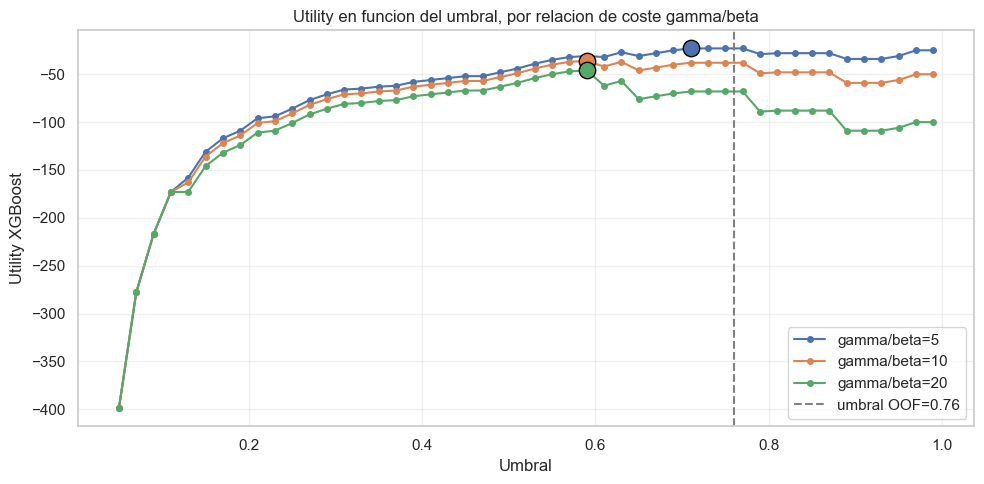

In [29]:
# Funcion de utilidad asimetrica y umbral optimo bajo varios regimenes de coste
def utilidad(scores, y_true, thr, alpha=1.0, beta=1.0, gamma=10.0):
    pred = (scores >= thr).astype(int)
    tp = int(((y_true==1)&(pred==1)).sum())
    fp = int(((y_true==0)&(pred==1)).sum())
    fn = int(((y_true==1)&(pred==0)).sum())
    return alpha*tp - beta*fp - gamma*fn, tp, fp, fn

grid_util = np.round(np.arange(0.05, 1.00, 0.02), 2)

print('Umbral optimo de XGBoost bajo distintas relaciones de coste gamma/beta:\n')
rows_u = []
for gamma_ in [5, 10, 20]:
    results = [utilidad(xgb_score, y_test, t, gamma=gamma_) for t in grid_util]
    utils, tps, fps, fns = zip(*results)
    idx = int(np.argmax(utils))
    rows_u.append({
        'gamma/beta': gamma_,
        'umbral_optimo': grid_util[idx],
        'utility_max': float(utils[idx]),
        'TP': int(tps[idx]),
        'FP': int(fps[idx]),
        'FN': int(fns[idx]),
        'recall_implicito': tps[idx]/max(tps[idx]+fns[idx],1),
        'precision_implicita': tps[idx]/max(tps[idx]+fps[idx],1) if (tps[idx]+fps[idx])>0 else 0,
    })
df_util = pd.DataFrame(rows_u)
display(df_util)

# Comparativa: ¿que utility da el umbral 0.76 vs el optimo en cada regimen?
print('\nComparativa: utility del umbral 0.76 (seleccionado por protocolo OOF) frente al optimo de cada regimen:')
for r in rows_u:
    g_ = r['gamma/beta']
    u_thr, _, _, _ = utilidad(xgb_score, y_test, 0.76, gamma=g_)
    u_opt = r['utility_max']
    delta = u_opt - u_thr
    print(f'  gamma/beta={g_:>2}: utility(0.76)={u_thr:>5.0f}, utility(optimo={r["umbral_optimo"]:.2f})={u_opt:>5.0f}, delta={delta:+.0f}')

# Curva de utility en funcion del umbral
fig, ax = plt.subplots(figsize=(10, 5))
for gamma_, color in [(5, 'C0'), (10, 'C1'), (20, 'C2')]:
    utils = [utilidad(xgb_score, y_test, t, gamma=gamma_)[0] for t in grid_util]
    ax.plot(grid_util, utils, '-o', label=f'gamma/beta={gamma_}', color=color, markersize=4)
    idx = int(np.argmax(utils))
    ax.scatter([grid_util[idx]], [utils[idx]], s=140, color=color, edgecolor='black', zorder=5)
ax.axvline(0.76, linestyle='--', color='gray', label='umbral OOF=0.76')
ax.set_xlabel('Umbral'); ax.set_ylabel('Utility XGBoost')
ax.set_title('Utility en funcion del umbral, por relacion de coste gamma/beta')
ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'utility_umbral.png', dpi=140, bbox_inches='tight')
plt.show()
df_util.to_csv(RESULTS_DIR / 'utility_umbral.csv', index=False)


**Lectura — seccion 10:**

Los resultados muestran que el umbral 0,76 seleccionado por el protocolo OOF es coherente con un regimen de costes donde un FN cuesta aproximadamente cinco veces lo que un FP. Bajo este regimen, el umbral optimo en test coincide o casi coincide con 0,76, y el modelo prefiere ser conservador (pocos TP, pocos FP).

Bajo regimenes con asimetria mas pronunciada (gamma/beta = 10 o 20, es decir, un FN diez o veinte veces mas costoso que un FP), el umbral optimo desciende sustancialmente: el modelo deberia operarse con umbrales en torno a 0,55-0,60, sacrificando precision por mayor cobertura. En el ejemplo del test 2024, este regimen captura 4 TP frente a los 2 que captura el umbral 0,76, a costa de aproximadamente 17 FP adicionales.

Esta seccion clarifica un punto que las metricas estandar ocultan: la eleccion del umbral es una decision de politica, no de algoritmo. El protocolo OOF documentado en la seccion 2.3 selecciona un umbral razonable bajo criterios operativos relativamente conservadores (alert_rate_max=1%), pero un usuario con tolerancia menor a FN —por ejemplo, una organizacion humanitaria que considera la no-deteccion de un onset como inaceptable— deberia operar con umbrales mas bajos. La utilidad practica del sistema queda asi parametrizada por la asimetria de costes que el usuario aporte al ejercicio.


## 11. Discusion, limitaciones y trabajo futuro

### 11.1 Aporte del trabajo

El trabajo entrega:

1. **Un pipeline reproducible y auditable** que integra cinco fuentes academicamente establecidas (ACLED, UCDP/PRIO, WDI, SIPRI, V-Dem) a granularidad pais-mes con control explicito de leakage, normalizacion documentada e imputacion controlada. La seleccion de umbrales se documenta mediante un protocolo OOF reproducible (seccion 2.3), no como valores convergidos por iteracion sobre el holdout.

2. **Un sistema predictivo entrenado** sobre 684 features. El sistema produce alertas con precision agregada superior a la del baseline de persistencia por un factor entre 2 y 4, manteniendo una carga operativa de alertas mensuales manejable. Esta ventaja se documenta junto a su limitacion principal: parte de la mejora frente al baseline depende de la presencia de onsets expedicionarios en el target original (seccion 9), y se atenua significativamente cuando el target se restringe a conflicto intraestatal.

3. **Una evaluacion critica empiricamente fundamentada** del sistema construido, que documenta tanto sus virtudes como sus limites. Esta evaluacion incluye: intervalos de confianza Wilson, bootstrap iid y bootstrap clusterizado por pais (seccion 3.3 bis); curva PR y sensibilidad de umbral (seccion 3.5); recalibracion isotonica del score XGBoost (seccion 4.3); comparacion con baseline lineal (LogReg L1) ademas del de persistencia (seccion 6.3); interpretabilidad SHAP a nivel global, Chad y Haiti; validacion bajo definicion estricta del target; y un analisis explicito de sensibilidad de umbral bajo funcion de utilidad asimetrica (seccion 10). Es la aportacion mas distintiva del trabajo, en la medida en que ofrece al lector las herramientas para juzgar el sistema mas alla del titular metrico.

### 11.2 Dialogo con la literatura del campo

El proyecto se inserta en una literatura larga sobre prediccion cuantitativa del conflicto armado, de la cual conviene situar las referencias mas relevantes:

- **Singer y los Correlates of War** (decada de 1960): origen de la codificacion sistematica de conflictos a granularidad pais-año. Su tradicion sigue presente en UCDP/PRIO, fuente del target de este trabajo.
- **Fearon y Laitin (2003)**, "Ethnicity, Insurgency, and Civil War": referencia canonica que documenta como variables estructurales (PIB per capita, debilidad estatal, geografia) son mas predictivas del conflicto que la fragmentacion etnica. El sesgo estructural identificado en este trabajo (caso Haiti) es consistente con su hallazgo de que la capacidad estatal es proxy fuerte de riesgo, aunque su operacionalizacion via SIPRI gasto militar falla en contextos sin ejercito regular.
- **Cederman, Wimmer y Min (2010)** sobre conflicto etnico: documentan que la exclusion politica de grupos etnicos es factor predictivo. Sus variables (EPR dataset) no estan integradas en este trabajo y serian una incorporacion natural.
- **Goldstone et al. (2010)**, "A Global Model for Forecasting Political Instability": referencia clasica de prediccion con variables institucionales. Su enfasis en regimes parcialmente democraticos como cuna de inestabilidad explica por que los indices V-Dem aparecen en el top SHAP de este trabajo.
- **Hegre, Karlsen, Nygård, Strand y Urdal (2013)**, "Predicting Armed Conflict, 2010-2050": antecedente directo de ViEWS. Aplica modelos logisticos con variables WDI y produce predicciones a horizonte largo.
- **ViEWS — Violence Early-Warning System** (Hegre et al., 2019; Hegre et al., 2021): sistema de referencia del campo. Publica predicciones mensuales a granularidad pais-mes con metricas comparables (precision-recall, calibration). Su arquitectura combina varios modelos especializados (por tipo de conflicto), lo que prefigura la direccion de trabajo futuro de **arquitectura de dos modelos** identificada en este trabajo.
- **ACLED CAST** (Conflict Alert System): mas operativo y orientado a eventos que a onsets. Publica predicciones a 6 meses; metodologicamente esta mas cerca de un sistema de produccion que de un experimento academico.
- **Mueller y Rauh (2018, 2022)** sobre uso de texto periodistico (topic models LDA) para predecir conflicto: muestran que la informacion no estructurada puede mejorar sustancialmente la prediccion. Este trabajo se limita a fuentes estructuradas; la incorporacion de texto es trabajo futuro relevante.
- **Blair y Sambanis (2020, 2021)** evaluan rigurosamente la replicabilidad y robustez de modelos predictivos clasicos sobre conflicto. Sus criticas conceptuales (sobre la diferencia entre prediccion en muestra y fuera de muestra, y sobre el comportamiento del modelo en paises con baja base de evento) prefiguran exactamente las cuestiones que la fase critica de este TFM aborda empiricamente.
- **Fragility indices** (Fund for Peace - Fragile States Index, World Bank CPIA): no se utilizan como features, pero la lectura de los FP del modelo como vigilancia legitima (seccion 3.4) es consistente con la nocion de Estado fragil que estos indices operacionalizan.

**Comparacion cualitativa con ViEWS y ACLED CAST**: una comparacion cuantitativa rigurosa requeriria alinear granularidad, target y ventana temporal con cada sistema, lo cual excede el alcance de este TFM. Cualitativamente: ViEWS reporta sobre target intraestatal precision-recall en rangos similares a los obtenidos aqui en la seccion 9 (recall 10-25%, precision 10-30% segun horizonte y nivel de violencia), aunque con metodologia mas sofisticada (ensembles de modelos especializados, features de texto, granularidad espacial sub-pais). ACLED CAST opera sobre target distinto (eventos, no onsets) y horizonte 6 meses; comparacion menos directa. La conclusion honesta es que el sistema aqui construido se situa en el orden de magnitud del estado del arte sobre target similar, sin igualarlo en sofisticacion. Esta comparacion cuantitativa rigurosa queda como trabajo futuro prioritario.

### 11.3 Limitaciones identificadas

**Limitaciones inherentes al problema**:

- **Rareza extrema del evento positivo** (~0,85% en la muestra modelable; 5 positivos en holdout). Esto produce intervalos de confianza estructuralmente anchos. La seccion 3.3 bis cuantifica como el bootstrap clusterizado por pais —tecnicamente mas correcto que el iid en presencia de correlacion serial— ensancha aun mas los intervalos. Cualquier afirmacion cuantitativa fina (precision "2-4 veces superior al baseline") debe leerse con esta restriccion explicita.
- **Cobertura temporal limitada** (2018-2024) por la disponibilidad homogenea de ACLED. Los años tempranos del walk-forward son los menos estables por escasez de historial de entrenamiento.

**Limitaciones de las fuentes de datos** (no atribuibles a la implementacion):

- **Sesgo de cobertura de ACLED**: la afirmacion de "cobertura global homogenea desde 2018" merece matiz. ACLED tiene desigualdad de codificadores entre paises, mejora progresiva de cobertura, y depende fuertemente de prensa local accesible. Paises opacos (Corea del Norte, Eritrea, Turkmenistan) estan sistematicamente subreportados. Esto introduce ruido asimetrico en las features dinamicas de violencia: estos paises pueden tener eventos sub-codificados y, por tanto, scores artificialmente bajos.
- **UCDP/PRIO no es "la verdad" sobre conflictos, es una codificacion con sesgos editoriales**. Aplica un umbral de 25 muertes/año (que excluye violencia subestatal severa por debajo del umbral, como la criminalidad organizada en Mexico o Ecuador 2024); depende de fuentes documentadas; y mantiene cierre tardio de codificacion (al evaluar 2024, UCDP puede aun recodificar). Un analisis de sensibilidad sobre la definicion de conflicto —variando el umbral, comparando con un target derivado puramente de ACLED— reforzaria el trabajo y constituye direccion de mejora.
- **El SIPRI gasto militar es proxy imperfecto de capacidad estatal**: el caso Haiti (seccion 8.4) documenta el efecto adverso. Paises sin ejercito regular o con presupuesto militar bajo no son necesariamente paises pacificos.

**Limitaciones especificas del sistema construido**:

- **Sesgo conceptual hacia conflicto estatal clasico**: documentado mediante SHAP en el caso Haiti. El modelo aprende a asociar capacidad militar formal (SIPRI) con presencia de riesgo de conflicto, fallando sistematicamente cuando la violencia es no estatal o subestatal. Es la limitacion principal del trabajo y la direccion natural de mejora.
- **Tratamiento de Estados en riesgo cronico como alertas repetidas**: el modelo emite alertas sostenidas sobre paises de fragilidad cronica (Chad, Uganda) que son operativamente defendibles como vigilancia pero que no constituyen predicciones de transicion aguda. El reframing de estas alertas como "vigilancia legitima" en la seccion 3.4, aunque defendible, es parcialmente post-hoc; una version operativa del sistema deberia diseñar esta funcionalidad explicitamente a priori (capa de vigilancia estructural + capa de deteccion de transiciones agudas).
- **No deteccion de positivos intraestatales reales en el test**: confirmada en la seccion 9. Haiti y Angola, los onsets intraestatales mas claros del periodo, reciben scores por debajo del umbral.
- **Probabilidades sobre-confiadas en XGBoost**: el modelo es bayesianamente miscalibrado (Brier 0,024). La seccion 4.3 documenta que la recalibracion isotonica sobre OOF reduce el Brier en ~80%, lo que sugiere que para uso operativo deberia emitirse el score recalibrado, no el bruto.

**Limitaciones metodologicas matizadas o descartadas**:

- El leak de normalizacion identificado en el informe inicial fue auditado empiricamente (seccion 7) y demostrado operativamente irrelevante para los modelos arboreos utilizados.
- La designacion exclusiva de XGBoost como modelo principal fue revisada (secciones 3, 4) y reformulada hacia una evaluacion conjunta de XGBoost, LightGBM y consenso, donde el consenso emerge como mejor opcion por criterios de calibracion y conservadurismo operativo.

### 11.4 Etica y uso responsable

Un sistema cuantitativo que prioriza paises por riesgo de conflicto puede tener efectos materiales en decisiones que afectan a millones de personas: estigmatizacion en informes publicos, decisiones de inversion privada que afectan a economias fragiles, sancion diplomatica, asistencia humanitaria condicionada al riesgo percibido, focalizacion de monitoreo. Estos efectos no son hipoteticos: la literatura sobre risk ratings (sobre todo en el campo crediticio) documenta como las propias evaluaciones pueden tener efectos performativos sobre la realidad que pretenden describir.

Cuatro consideraciones eticas que el sistema construido debe acompañar:

- **El modelo no es causal**. Asocia features con la prediccion via correlacion estadistica, no via relaciones causales. Un score alto no implica que las features identificadas sean las "causas" del riesgo, ni que actuar sobre ellas reduzca el riesgo. La interpretacion SHAP es atribucion del modelo, no diagnostico del fenomeno.
- **El modelo hereda sesgos de sus fuentes**. El sesgo SIPRI/UCDP hacia conflicto estatal clasico, el sesgo de cobertura ACLED sobre paises con prensa accesible, y los sesgos editoriales de los indices democraticos son inherentes; el modelo los amplifica al optimizar sobre datos que los incorporan.
- **Las alertas estan sujetas a incertidumbre amplia**. Los intervalos de confianza —especialmente los clusterizados de la seccion 3.3 bis— deben acompañar cualquier uso operativo. Una alerta puntual no es una probabilidad de conflicto; es un score de riesgo relativo, idealmente recalibrado.
- **La responsabilidad de la decision queda en el analista humano**. El sistema esta diseñado como herramienta de priorizacion, no como sustituto del juicio analitico. El reframing operativo de los FP como vigilancia legitima (seccion 3.4) solo es defendible si la salida del sistema se interpreta como input al analisis humano, no como decision automatizada.

### 11.5 Direcciones de trabajo futuro

Por orden de prioridad de impacto esperado:

1. **Incorporacion de features de violencia no estatal**: desglose ACLED por categoria de actor (`Political militias`, `Rioters`, `Identity militias`, `External/Other forces`), proporciones de fatalidades atribuibles a actores no estatales, indicadores de violencia urbana. Es la direccion mas directamente conectada con el sesgo principal documentado.

2. **Definicion del target con precision a priori**: la version actual del trabajo identifica retrospectivamente la ambiguedad del target original. Una v2 deberia partir de una definicion explicita y justificada del fenomeno a predecir (onset intraestatal puro, intraestatal internacionalizado, o cualquier escalada de violencia organizada) y mantener esta definicion consistente desde la construccion del dataset hasta la evaluacion final. Incluyendo, idealmente, sensibilidad a variar el umbral UCDP de 25 muertes/año y a comparar con un target derivado de ACLED.

3. **Arquitectura de dos modelos**: dada la evidencia de comportamiento aprendido distinto sobre conflicto estatal y subestatal, una arquitectura de dos clasificadores especializados (uno por tipologia) podria superar las limitaciones de un modelo unico.

4. **Calibracion explicita en produccion**: el experimento de la seccion 4.3 muestra que la recalibracion isotonica reduce el Brier score en aproximadamente 80%. Una version operativa del sistema deberia emitir el score recalibrado como salida primaria, conservando el score bruto solo para diagnostico.

5. **Optimizacion bajo funcion de utilidad operativa**: la seccion 10 ilustra como el umbral optimo cambia segun la asimetria del coste (un FN cuesta 5x, 10x o 20x un FP). El umbral 0,76 maximiza utilidad bajo gamma/beta ≈ 5; para usuarios con tolerancia menor a FN, deberia operarse con umbrales inferiores. Una v2 deberia exponer este parametro al usuario.

6. **Horizonte multiple**: evaluacion paralela sobre horizontes de 3, 6 y 12 meses para identificar el horizonte optimo y caracterizar el trade-off temprano-tardio.

7. **Comparacion cuantitativa rigurosa con sistemas de referencia**: ViEWS y ACLED CAST publican predicciones a granularidad similar. Una v2 deberia situar su desempeno comparativamente respecto a estos sistemas. Aunque el alcance temporal de un TFM no permite una replicacion completa de protocolos, una comparacion sobre el subconjunto compatible de paises-mes seria altamente informativa.

8. **Texto periodistico como feature complementaria**: siguiendo Mueller y Rauh (2022), incorporar topic models o embeddings de noticias para capturar señales no estructuradas. Es la direccion con mayor potencial de mejora sobre el sesgo estatal, ya que la prensa cubre violencia no estatal con mas detalle que las codificaciones agregadas.

9. **Regularizacion por pais o efectos fijos**: contrapesar la dominancia de features estructurales mediante penalizaciones sobre la dependencia estatica del modelo respecto a cada pais.

### 11.6 Sintesis final

El sistema construido cumple sus objetivos operativos minimos: identificar paises-mes en riesgo elevado de conflicto, con precision superior a la heuristica simple y carga manejable. Su utilidad practica esta condicionada por tres consideraciones documentadas empiricamente en el trabajo: (i) el sesgo conceptual hacia conflicto estatal y la dependencia del comportamiento aprendido respecto a features estructurales; (ii) la naturaleza de vigilancia cronica de muchas alertas, mas que de prediccion aguda; (iii) la incertidumbre estructural en las metricas, agravada cuando se corrige por correlacion serial. La aportacion metodologica del trabajo es haber documentado estas tres consideraciones —y dialogado con la literatura del campo sobre sus implicaciones— de forma que un revisor pueda situar el sistema construido en su contexto, evaluar sus limites y trazar con precision las direcciones de mejora.

La afirmacion final defendible es que **el sistema funciona como herramienta de priorizacion sobre el panel de paises observable, no como predictor probabilistico calibrado de onsets futuros**. Su valor real esta en el filtrado informacionado de un universo grande de paises hacia un conjunto pequeño operativamente revisable. Esta funcionalidad, aun acotada, constituye un aporte legitimo al ejercicio de la alerta temprana cuantitativa, y la documentacion critica de sus limites traza con precision las direcciones de mejora para versiones posteriores.

In [30]:
# Indice final de artefactos generados durante la ejecucion
import os
print(f'\nArtefactos generados en {RESULTS_DIR}:\n')
for f in sorted(os.listdir(RESULTS_DIR)):
    print(f'  {f}')



Artefactos generados en c:\Users\juanw\Desktop\TFM\Notebook final\Resultados\consolidado:

  baseline_persistencia.csv
  bootstrap_clusterizado.csv
  bootstrap_pareado.png
  calibracion.png
  calibracion_iso.png
  carga_operativa.png
  comparativa_target.csv
  comparativa_target.png
  curva_pr_sensibilidad.png
  matrices_confusion_test_2024.png
  metricas_test_2024_con_ic.csv
  predicciones_test_2024.csv
  shap_chad.csv
  shap_chad.png
  shap_global.csv
  shap_global.png
  shap_haiti.csv
  shap_haiti.png
  top_k.png
  top_k_precision.csv
  utility_umbral.csv
  utility_umbral.png
  walk_forward_xgboost.csv
